# Generating & Validating the Synthetic Data

The notebook is organized into two parts. **Part 1** generates the market: households, latent taste classes, data demand, the plan catalog and its price history, 24 months of plan choices and churn, a stated-preference conjoint, and the withheld counterfactual launch of the candidate `essentials` plan. **Part 2** validates it, confirming the panel is plausible and that the structures the modeling notebook needs to find are actually present. No proprietary data was used anywhere in this project; every value was generated from parameters chosen to produce plausible behavior.

The study is framed as a pre-launch decision. The modeling notebook sees only the 24 months before launch plus a conjoint survey, and must forecast how many customers would take the new plan and where they would come from. The generator also draws the launch itself, twice per household on shared random numbers: once with the existing portfolio and once with `essentials` added. Because both worlds share every random draw, the difference between them is the exact per-household effect of the launch. True cannibalization is therefore a known quantity rather than an estimate, and the forecast can be scored against it.

---

## Part 1 · Generating the Synthetic Data

This part runs in twelve steps, each depending only on the ones above it.

1. **Markets & households**: 40 markets and 80,000 households, including households currently with a competitor or outside the postpaid market, so acquisition is part of the population rather than an assumption.
2. **Latent classes & part-worths**: four taste classes with distinct price and feature coefficients; membership partly predictable from observables.
3. **Data demand**: per-household monthly data, hotspot, and roaming needs, correlated with class.
4. **Plan catalog & price history**: seven alternatives, a price increase at month 6, regional promotions in months 9–12, and the launch of `value` at month 14.
5. **Feature surplus**: plan attributes converted into household-specific costs, such as expected throttled GB under each plan's cap.
6. **Choice mechanics**: a nested utility structure with errors drawn explicitly, so different worlds can share the same draws.
7. **Consideration**: the monthly probability that a household re-evaluates its plan at all.
8. **Monthly history**: 24 months of usage, plan migrations, gross adds, and churn.
9. **Conjoint**: a stated-preference survey of 4,000 households with deliberate hypothetical bias.
10. **Counterfactual launch**: paired 12-month worlds with and without `essentials`, across a grid of prices, bundles, and eligibility rules.

Sanity checks and the ground-truth export follow as steps 11–12, then Part 2 picks up directly from what's in memory.

In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.special import logsumexp, softmax
from IPython.display import display

In [2]:
# Synthetic Data Parameters
SEED = 20260916
RNG = np.random.default_rng(SEED)
DATA = Path('synthetic')
DATA.mkdir(parents = True, exist_ok = True)

N_HOUSEHOLDS = 80_000
N_MARKETS = 40
N_MONTHS = 24
N_HORIZON = 12

# Timeline
PRICE_CHANGE_MONTH = 6
PRICE_CHANGE = 5.0
PROMO_MONTHS = [9, 10, 11, 12]
PROMO_DISCOUNT = 10.0
VALUE_LAUNCH_MONTH = 14
LAUNCH_WINDOW = 3

# Pricing & Cost
ADDL_LINE_RATE = 0.65
NETWORK_COST_PER_LINE = 16.0
DATA_COST_PER_GB = 0.35
ROAM_COST_PER_DAY = 3.0

# Behavior
BASE_CHURN = 0.0050
SERVICE_CHURN = 0.0025
SERVICE_CHURN_CARE_LIFT = 0.0040
SIGMA_WITHIN = 0.35
THROTTLED_USE_RATE = 0.45

# Nesting
LAMBDA_PREMIUM_TIER = 0.60
LAMBDA_VALUE_TIER = 0.75
LAMBDA_VALUE_PAIR = 0.35

# Conjoint
N_RESPONDENTS = 4_000
NONCUSTOMER_SHARE = 0.25
N_TASKS = 10
N_PROFILES = 3
CONJOINT_HOLDOUTS = [
    # (price_per_line, data_gb, hotspot_gb, stream_tier, roaming_tier, perks_value)
    [(45.0, 20.0, 0.0, 0, 0, 0.0), (70.0, 50.0, 15.0, 1, 1, 0.0), (95.0, np.inf, 50.0, 2, 2, 12.0)],
    [(35.0, 10.0, 0.0, 0, 0, 0.0), (55.0, 20.0, 5.0, 1, 0, 0.0), (80.0, np.inf, 30.0, 1, 1, 8.0)],
]
N_HOLDOUT_TASKS = len(CONJOINT_HOLDOUTS)
SP_PRICE_ATTENUATION = 0.70
SP_SCALE = 0.75
SP_KEEP_CURRENT_BIAS = -0.50

# Counterfactual Grid
ESSENTIALS_PRICES = np.arange(35.0, 55.1, 2.5)
REFERENCE_PRICE = 45.0

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
CLASS_COLORS = [ACCENT2, ACCENT, '#1f9e89', '#7b4fc9']

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

## 1 · Markets & Households

**Purpose:** Generates 40 markets and 80,000 households with the observable fields a carrier would hold: lines, age band, device tier, local income tier, and autopay. The population deliberately includes households that are currently with a competitor or outside postpaid entirely, since a new low-priced plan can win customers as well as downgrade existing ones.

**Design Notes:**

1. Markets carry three fields that matter later
  - competitive_intensity: raises the pull of competitor plans, and decides which markets received the month 9–12 promotion
  - income_index: shifts local income, and through it device tier and class membership
  - launch_intensity: quiet / standard / heavy marketing for the counterfactual launch, randomized across markets so the modeling notebook has a clean experiment to evaluate
2. Promotions go to the most competitive third of markets, not at random; that is the intentional confounding checked in Part 2 §4
3. Household carrier is not assigned here; it falls out of the initial choice draw in §8, so market share is a consequence of preferences rather than a separate assumption
4. The 80,000 households are the carrier's customers plus a pool of households that could realistically switch, not the whole national market; the carrier's share of this pool is therefore well above a national market share

**Real-World Estimation:**

1. All fields here are observable for current customers from billing and CRM records
2. For competitor and outside households, only market-level data and survey screeners are available; that asymmetry is carried into the conjoint in §9

**Observations:**

- _To be written once parameters are final._

In [3]:
# Generate Markets & Households
def make_markets(n, rng):

    competitive_intensity = rng.beta(2.0, 2.0, size = n)

    return pd.DataFrame({
        'market_id': np.arange(n),
        'competitive_intensity': competitive_intensity,
        'income_index': rng.normal(0, 1, size = n),
        'promo_market': competitive_intensity >= np.quantile(competitive_intensity, 2 / 3),
        'launch_intensity': rng.permutation(np.resize([0, 1, 2], n)),
    })


def make_households(n, markets, rng):

    market_id = rng.integers(0, len(markets), size = n)
    m = markets.set_index('market_id').loc[market_id]

    lines = rng.choice([1, 2, 3, 4, 5], size = n, p = [0.34, 0.30, 0.18, 0.12, 0.06])
    age_band = rng.choice(['18-29', '30-44', '45-64', '65+'], size = n, p = [0.20, 0.30, 0.32, 0.18])

    income_score = 0.6 * m['income_index'].to_numpy() + rng.normal(0, 0.8, size = n)
    zip_income_tier = np.select([income_score < -0.5, income_score > 0.6], ['low', 'high'], 'mid')

    device_score = (
        0.8 * income_score +
        0.4 * (age_band == '18-29') -
        0.5 * (age_band == '65+') +
        rng.normal(0, 0.8, size = n)
    )
    device_tier = np.select([device_score < -0.6, device_score > 0.5], ['budget', 'flagship'], 'mid')

    autopay = rng.random(n) < 1 / (1 + np.exp(-(0.8 + 0.3 * income_score)))

    return pd.DataFrame({
        'household_id': np.arange(n),
        'market_id': market_id,
        'lines': lines,
        'age_band': age_band,
        'zip_income_tier': zip_income_tier,
        'device_tier': device_tier,
        'autopay': autopay,
        'competitive_intensity': m['competitive_intensity'].to_numpy(),
        'tenure_months': rng.integers(1, 121, size = n),
    })

markets = make_markets(N_MARKETS, RNG)
households = make_households(N_HOUSEHOLDS, markets, RNG)
households.head()

,household_id,market_id,lines,age_band,zip_income_tier,device_tier,autopay,competitive_intensity,tenure_months
0,0,20,1,45-64,high,flagship,True,0.617086,94
1,1,15,1,18-29,mid,mid,False,0.278452,119
2,2,21,2,65+,mid,mid,False,0.520974,97
3,3,23,2,45-64,mid,budget,True,0.561020,95
4,4,7,2,18-29,low,budget,False,0.786899,87


## 2 · Latent Classes & Part-Worths

**Purpose:** Assigns every household to one of four taste classes and draws its individual part-worths: how much utility it gets from a dollar of price, a GB of throttled data, a GB of missing hotspot allowance, a streaming quality step, an uncovered roaming day, and a dollar of perks. These are the hidden traits that drive every choice downstream, and the quantities the latent class model is scored on.

**Design Notes:**

1. Four classes, each with a distinct reason to prefer a plan
  - Budget-Constrained: highly price-sensitive, nearly indifferent to features; the natural audience for a cheaper plan
  - Data-Hungry: heavy users who pay for data and streaming quality; the cannibalization risk if the new plan is too generous
  - Family Anchor: multi-line households with high inertia and switching costs; exposed through the multi-line discount
  - Premium Convenience: price-insensitive, pays for roaming, hotspot, 4K, and perks; should almost never move to the new plan
2. Membership is a softmax over observables plus Gumbel noise, so class is partly but not fully predictable; the latent class model has real signal to find and a ceiling on how well it can find it
3. Individual coefficients = class mean × a mean-one lognormal multiplier (spread 0.25), so hierarchical Bayes on the conjoint has genuine within-class variation to recover, and no coefficient changes sign
4. Competitor pull rises with market competitive intensity plus household noise
5. Coefficients are starting values tuned against the §11 targets, not settled constants

**Real-World Estimation:**

1. None of these are observable; they can only be inferred from choices made under variation in price and features
2. Revealed choices identify price and constants poorly (few plans, confounded bundles); the conjoint supplies attribute trade-offs, and joint RP–SP estimation reconciles the two
3. Class membership is estimated as a function of observables, then scored onto the full base

**Observations:**

- _To be written once parameters are final._

In [4]:
# Assign Latent Classes & Part-Worths
CLASSES = ['budget_constrained', 'data_hungry', 'family_anchor', 'premium_convenience']
CLASS_LABELS = ['Budget-Constrained', 'Data-Hungry', 'Family Anchor', 'Premium Convenience']

TASTES = pd.DataFrame({
    'b_price':        [-0.095, -0.065, -0.080, -0.025],
    'b_throttle':     [-0.010, -0.060, -0.030, -0.045],
    'b_hotspot':      [-0.005, -0.030, -0.020, -0.040],
    'b_stream':       [ 0.050,  0.250,  0.200,  0.400],
    'b_roam':         [-0.020, -0.100, -0.150, -0.450],
    'b_perks':        [ 0.004,  0.010,  0.012,  0.022],
    'inertia':        [ 1.10,   1.40,   2.20,   1.80],
    'switch_cost':    [ 0.60,   0.80,   1.40,   1.00],
    'asc_competitor': [-1.00,  -0.95,  -1.20,  -1.20],
    'asc_outside':    [-1.60,  -2.40,  -2.20,  -3.20],
}, index = CLASSES)

PART_WORTHS = ['b_price', 'b_throttle', 'b_hotspot', 'b_stream', 'b_roam', 'b_perks']
COMPETITIVE_PULL = 2.0
TASTE_SPREAD = 0.25


def class_logits(h):

    low = h['zip_income_tier'].eq('low').to_numpy()
    high = h['zip_income_tier'].eq('high').to_numpy()
    budget_device = h['device_tier'].eq('budget').to_numpy()
    flagship = h['device_tier'].eq('flagship').to_numpy()
    young = h['age_band'].eq('18-29').to_numpy()
    family_age = h['age_band'].eq('30-44').to_numpy()
    senior = h['age_band'].eq('65+').to_numpy()
    big = (h['lines'] >= 3).to_numpy()

    return np.column_stack([
        -0.35 + 0.9 * low + 0.8 * budget_device + 0.6 * senior - 0.3 * big,
        -0.05 + 1.0 * young + 0.6 * flagship - 0.4 * big - 0.6 * senior,
        -0.70 + 1.6 * big + 0.4 * family_age,
        -0.45 + 1.0 * flagship + 0.9 * high - 0.8 * low + 0.3 * senior,
    ])


def assign_tastes(h, rng):

    n = len(h)
    k = (class_logits(h) + rng.gumbel(size = (n, len(CLASSES)))).argmax(axis = 1)
    t = TASTES.iloc[k].reset_index(drop = True)

    out = pd.DataFrame({'household_id': h['household_id'], 'class_id': k, 'latent_class': np.array(CLASSES)[k]})

    for col in PART_WORTHS:
        multiplier = np.exp(TASTE_SPREAD * rng.normal(size = n) - TASTE_SPREAD ** 2 / 2)
        out[col] = t[col].to_numpy() * multiplier

    out['inertia'] = t['inertia'].to_numpy() + rng.normal(0, 0.20, size = n)
    out['switch_cost'] = t['switch_cost'].to_numpy() + rng.normal(0, 0.15, size = n)
    out['asc_competitor'] = (
        t['asc_competitor'].to_numpy() +
        COMPETITIVE_PULL * (h['competitive_intensity'].to_numpy() - 0.5) +
        rng.normal(0, 0.30, size = n)
    )
    out['asc_outside'] = t['asc_outside'].to_numpy() + rng.normal(0, 0.30, size = n)

    return out

tastes = assign_tastes(households, RNG)
display(
    tastes.groupby('latent_class')[PART_WORTHS + ['inertia', 'switch_cost']].mean().round(3)
        .reindex(CLASSES).assign(share = tastes['latent_class'].value_counts(normalize = True).round(3))
        .rename_axis(None)
)

,b_price,b_throttle,b_hotspot,b_stream,b_roam,b_perks,inertia,switch_cost,share
budget_constrained,-0.095,-0.010,-0.005,0.050,-0.02,0.004,1.099,0.599,0.304
data_hungry,-0.065,-0.060,-0.030,0.250,-0.10,0.010,1.395,0.799,0.239
family_anchor,-0.080,-0.030,-0.020,0.199,-0.15,0.012,2.199,1.401,0.238
premium_convenience,-0.025,-0.045,-0.040,0.399,-0.45,0.022,1.799,0.999,0.219


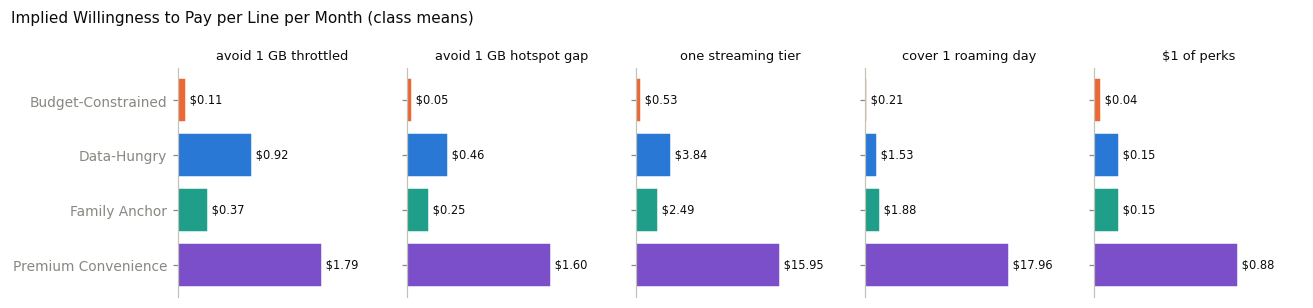

In [5]:
# Plot: Willingness to Pay by Class
WTP_FEATURES = [
    ('b_throttle', 'avoid 1 GB throttled', 1.0),
    ('b_hotspot', 'avoid 1 GB hotspot gap', 1.0),
    ('b_stream', 'one streaming tier', 1.0),
    ('b_roam', 'cover 1 roaming day', 1.0),
    ('b_perks', '$1 of perks', 1.0),
]

wtp = tastes.groupby('class_id')[PART_WORTHS].mean()
fig, axes = plt.subplots(1, len(WTP_FEATURES), figsize = (12, 2.8), sharey = True)

for ax, (col, label, unit) in zip(axes, WTP_FEATURES):
    values = (np.abs(wtp[col]) / -wtp['b_price']) * unit
    ax.barh(range(len(CLASSES)), values, color = CLASS_COLORS, edgecolor = SURFACE)
    for y, v in enumerate(values):
        ax.text(v, y, f' ${v:,.2f}', va = 'center', fontsize = 7.5, color = INK)
    ax.set_title(label, fontsize = 8.5)
    ax.set_xlim(0, values.max() * 1.45)
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)

axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_yticklabels(CLASS_LABELS)
axes[0].invert_yaxis()
fig.suptitle('Implied Willingness to Pay per Line per Month (class means)', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

## 3 · Data Demand

**Purpose:** Draws each household's underlying monthly need for data, hotspot, and roaming days. These are needs, not observed usage: what a household would use on an unconstrained plan. §8 turns them into observed usage under whatever plan the household is actually on.

**Design Notes:**

1. Data demand per line is lognormal
  - Household level: class median × lognormal spread (0.75), so heavy and light users exist inside every class and class medians overlap heavily
  - Month level: a further lognormal draw (0.35) around the household's own median, which is what makes a cap bind some months and not others
2. Hotspot is a minority behavior: a class-specific share of households use it at all, with lognormal need among users
3. Roaming is split into international days and North America days, since `standard` covers only the latter
4. Observed usage will be suppressed above the current plan's cap (§8), so the panel under-reports demand for exactly the customers whose plan binds

**Real-World Estimation:**

1. Usage, hotspot, and roaming days are observed for current customers, but only under their current plan
2. Demand above a cap is censored by throttling; recovering it needs a censored-data model (Tobit-style), or evidence from customers observed on more than one plan

**Observations:**

- _To be written once parameters are final._

In [6]:
# Draw Data Demand
USAGE = pd.DataFrame({
    'median_gb':          [7.0, 20.0, 11.0, 14.0],
    'hotspot_user_rate':  [0.30, 0.55, 0.45, 0.50],
    'hotspot_median_gb':  [2.0, 9.0, 4.0, 7.0],
    'intl_days':          [0.10, 0.30, 0.30, 0.90],
    'na_days':            [0.20, 0.35, 0.40, 0.60],
}, index = CLASSES)

SIGMA_BETWEEN = 0.75


def draw_demand(tastes, rng):

    n = len(tastes)
    u = USAGE.iloc[tastes['class_id'].to_numpy()].reset_index(drop = True)

    hotspot_user = rng.random(n) < u['hotspot_user_rate'].to_numpy()
    hotspot_need = np.where(
        hotspot_user, u['hotspot_median_gb'].to_numpy() * np.exp(rng.normal(0, 0.60, size = n)), 0.0
    )

    def mean_one(sd):
        return np.exp(sd * rng.normal(size = n) - sd ** 2 / 2)

    return pd.DataFrame({
        'household_id': tastes['household_id'],
        'usage_mu': np.log(u['median_gb'].to_numpy()) + rng.normal(0, SIGMA_BETWEEN, size = n),
        'hotspot_need_gb': hotspot_need,
        'intl_days_rate': u['intl_days'].to_numpy() * mean_one(1.1),
        'na_days_rate': u['na_days'].to_numpy() * mean_one(0.9),
    })

demand = draw_demand(tastes, RNG)
display(demand.assign(median_gb = np.exp(demand['usage_mu'])).drop(columns = 'usage_mu')
        .groupby(tastes['latent_class']).median().drop(columns = 'household_id').reindex(CLASSES).round(2).rename_axis(None))

,hotspot_need_gb,intl_days_rate,na_days_rate,median_gb
budget_constrained,0.00,0.05,0.13,7.06
data_hungry,3.97,0.16,0.24,19.98
family_anchor,0.00,0.16,0.27,10.93
premium_convenience,0.00,0.49,0.40,13.95


## 4 · Plan Catalog & Price History

**Purpose:** Defines the seven alternatives every household chooses among and the price history they faced. Revealed-preference data can only identify a price response if prices actually moved, so the variation is designed explicitly.

**Design Notes:**

1. Own plans: `premium`, `standard`, `value`, and the candidate `essentials`; competitor plans: `comp_premium`, `comp_value`; plus `outside` (prepaid or dropping the line)
2. Three historical events
  - Month 6: `standard` and `premium` rise by &#36;5 per line
  - Months 9–12: &#36;10 off `standard` in the most competitive third of markets
  - Month 14: `value` launches at &#36;50; this is the back-test, a real cheaper-plan launch the modeling notebook can forecast from months 1–13 and score against months 14–24
3. Multi-line discount: additional lines at 65% of list on own and competitor plans; `outside` is priced per line with no discount
4. `essentials` is unavailable throughout the history and only enters in §10

**Real-World Estimation:**

1. Own catalog and price history come from product and billing systems
2. Competitor offers come from public price tracking, usually at list price only, without promotions or retention offers

**Observations:**

- _To be written once parameters are final._

In [7]:
# Define Plan Catalog
ALTS = ['premium', 'standard', 'value', 'essentials', 'comp_premium', 'comp_value', 'outside']
A = {a: i for i, a in enumerate(ALTS)}
OWN = np.array([A['premium'], A['standard'], A['value'], A['essentials']])

CATALOG = pd.DataFrame(
    [
        ['own',         95.0, np.inf, 50.0, 2, 2, 12.0, 5.0, True],
        ['own',         70.0,  50.0,  15.0, 1, 1,  0.0, 0.0, True],
        ['own',         50.0,  15.0,   5.0, 0, 0,  0.0, 0.0, True],
        ['own',         45.0,  20.0,   0.0, 0, 0,  0.0, 0.0, True],
        ['competitor',  80.0, np.inf, 30.0, 1, 1,  8.0, 0.0, True],
        ['competitor',  45.0,  20.0,   5.0, 0, 0,  0.0, 0.0, True],
        ['outside',     30.0,   8.0,   0.0, 0, 0,  0.0, 0.0, False],
    ],
    index = ALTS,
    columns = ['carrier', 'list_price', 'data_gb', 'hotspot_gb', 'stream_tier', 'roaming_tier',
               'perks_value', 'perks_cost', 'multiline_discount'],
)
CARRIER = CATALOG['carrier'].to_numpy()
IS_OWN = CATALOG['carrier'].eq('own').to_numpy()

ESSENTIALS_BUNDLES = {
    'lean':         {'data_gb': 20.0, 'hotspot_gb': 0.0, 'stream_tier': 0},
    'lean_hotspot': {'data_gb': 20.0, 'hotspot_gb': 5.0, 'stream_tier': 0},
    'lean_30gb':    {'data_gb': 30.0, 'hotspot_gb': 0.0, 'stream_tier': 0},
    'lean_hd':      {'data_gb': 20.0, 'hotspot_gb': 0.0, 'stream_tier': 1},
}
ELIGIBILITY = ['open', 'no_multiline_discount', 'new_lines_only']


def catalog_for(bundle = 'lean', essentials_price = REFERENCE_PRICE, eligibility = 'open'):

    c = CATALOG.copy()
    for col, v in ESSENTIALS_BUNDLES[bundle].items():
        c.loc['essentials', col] = v
    c.loc['essentials', 'list_price'] = essentials_price
    c.loc['essentials', 'multiline_discount'] = eligibility != 'no_multiline_discount'

    return c


def history_prices(month):

    price = CATALOG['list_price'].to_numpy().copy()
    if month < PRICE_CHANGE_MONTH:
        price[[A['premium'], A['standard']]] -= PRICE_CHANGE

    available = np.ones(len(ALTS), dtype = bool)
    available[A['essentials']] = False
    if month < VALUE_LAUNCH_MONTH:
        available[A['value']] = False

    return price, available

price_history = pd.DataFrame(
    [
        {'month': m, 'plan': p, 'list_price': history_prices(m)[0][A[p]], 'available': history_prices(m)[1][A[p]]}
        for m in range(1, N_MONTHS + 1) for p in ALTS
    ]
)
display(CATALOG.rename_axis(None))

,carrier,list_price,data_gb,hotspot_gb,stream_tier,roaming_tier,perks_value,perks_cost,multiline_discount
premium,own,95.0,inf,50.0,2,2,12.0,5.0,True
standard,own,70.0,50.0,15.0,1,1,0.0,0.0,True
value,own,50.0,15.0,5.0,0,0,0.0,0.0,True
essentials,own,45.0,20.0,0.0,0,0,0.0,0.0,True
comp_premium,competitor,80.0,inf,30.0,1,1,8.0,0.0,True
comp_value,competitor,45.0,20.0,5.0,0,0,0.0,0.0,True
outside,outside,30.0,8.0,0.0,0,0,0.0,0.0,False


## 5 · Feature Surplus

**Purpose:** Converts plan attributes into household-specific costs, so a feature's value depends on the household's own needs rather than being the same for everyone. A 20 GB cap costs a 5 GB user nothing and costs a 35 GB user a great deal; this is the mechanism that makes cannibalization fall out of the model instead of being imposed on it.

**Design Notes:**

1. Throttle: expected GB per line above the cap each month, E[max(0, D − cap)] for lognormal D, in closed form
2. Hotspot gap: GB of hotspot need the plan does not cover
3. Roaming gap: expected roaming days per month the plan does not cover (international days unless the plan is tier 2; North America days unless tier 1 or above)
4. Streaming tier and perks value enter directly
5. All surplus terms are computed from true demand, not observed usage; the modeling notebook only has the latter

**Real-World Estimation:**

1. Computed from each customer's usage history as an empirical distribution, or a fitted per-customer distribution for short histories
2. Must correct for the censoring noted in §3: a customer on a 15 GB plan who uses 15.3 GB every month probably wants more

**Observations:**

- _To be written once parameters are final._

In [8]:
# Compute Feature Surplus
def throttled_gb(mu, cap):

    mu, cap = np.broadcast_arrays(np.asarray(mu, dtype = float), np.asarray(cap, dtype = float))
    finite = np.isfinite(cap)
    safe_cap = np.where(finite, cap, 1.0)
    d2 = (mu - np.log(safe_cap)) / SIGMA_WITHIN
    expected = np.exp(mu + SIGMA_WITHIN ** 2 / 2) * norm.cdf(d2 + SIGMA_WITHIN) - safe_cap * norm.cdf(d2)

    return np.where(finite, np.maximum(expected, 0.0), 0.0)


def feature_surplus(demand, catalog):

    mu = demand['usage_mu'].to_numpy()[:, None]
    hotspot = demand['hotspot_need_gb'].to_numpy()[:, None]
    intl = demand['intl_days_rate'].to_numpy()[:, None]
    na = demand['na_days_rate'].to_numpy()[:, None]
    roaming_tier = catalog['roaming_tier'].to_numpy()[None, :]

    return {
        'throttle': throttled_gb(mu, catalog['data_gb'].to_numpy()[None, :]),
        'hotspot': np.maximum(hotspot - catalog['hotspot_gb'].to_numpy()[None, :], 0.0),
        'roam': intl * (roaming_tier < 2) + na * (roaming_tier < 1),
        'stream': np.broadcast_to(catalog['stream_tier'].to_numpy()[None, :].astype(float), (len(demand), len(ALTS))),
        'perks': np.broadcast_to(catalog['perks_value'].to_numpy()[None, :], (len(demand), len(ALTS))),
    }

surplus = feature_surplus(demand, catalog_for('lean'))
display(
    pd.DataFrame(surplus['throttle'], columns = ALTS).groupby(tastes['latent_class']).mean()
        .reindex(CLASSES).round(2).rename_axis(None)
        .style.set_caption('Expected throttled GB per line per month, lean essentials')
)

,premium,standard,value,essentials,comp_premium,comp_value,outside
budget_constrained,0.000000,0.170000,1.930000,1.240000,0.000000,1.240000,3.940000
data_hungry,0.000000,4.180000,15.120000,12.300000,0.000000,12.300000,20.350000
family_anchor,0.000000,0.800000,5.210000,3.760000,0.000000,3.760000,8.620000
premium_convenience,0.000000,1.610000,8.290000,6.310000,0.000000,6.310000,12.470000


## 6 · Choice Mechanics

**Purpose:** Defines utility and the error structure behind every plan choice. Errors are drawn explicitly from a nested structure rather than sampled from choice probabilities, so a world with `essentials` and a world without it can share exactly the same draws. With shared draws, any household that behaves differently between the two worlds does so only because `essentials` exists.

**Design Notes:**

1. Utility = price × per-line price + surplus terms × part-worths + competitor or outside constant + inertia on the current plan − switching cost for changing carrier
2. Nesting is by price tier, not by carrier: loyalty to the carrier is already carried by inertia and switching cost
  - Premium tier (λ = 0.60): `premium`, `comp_premium`
  - `standard` stands alone
  - Value tier (λ = 0.75): `comp_value`, `outside`, and a tighter pair (λ = 0.35) of `value` and `essentials`
  - A cheap plan therefore substitutes mainly with other cheap options, and above all with `value`; a flat logit spreads its draw in proportion to share and overstates what it takes from `premium` and `standard`
  - This is the structure a multinomial logit cannot represent, and where its cannibalization estimate goes wrong
3. Errors follow the nested logit exactly: ε = λ·Gumbel + λ·log S, where S is a positive stable variable with index λ (Cardell 1997), applied once per nesting level
4. The check below compares simulated choice shares against analytic nested logit probabilities, and confirms that adding `essentials` under shared draws moves households only onto `essentials`

**Real-World Estimation:**

1. The nesting parameters are estimated, not assumed; λ near 1 would mean the nest adds nothing
2. Which tree to use is itself a modeling choice; competing trees (by tier, by carrier) are compared on fit and on holdout substitution patterns
3. In real data the counterfactual cannot be observed; this coupling exists only because the data is synthetic

**Observations:**

- _To be written once parameters are final._

In [9]:
# Define Choice Mechanics
def positive_stable(alpha, size, rng):

    u = np.clip(rng.uniform(0, np.pi, size), 1e-12, np.pi - 1e-12)
    e = rng.exponential(1.0, size)
    a = np.sin(alpha * u) ** (alpha / (1 - alpha)) * np.sin((1 - alpha) * u) / np.sin(u) ** (1 / (1 - alpha))

    return (a / e) ** ((1 - alpha) / alpha)


PREMIUM_TIER = [A['premium'], A['comp_premium']]
VALUE_TIER_SINGLES = [A['comp_value'], A['outside']]
VALUE_PAIR = [A['value'], A['essentials']]


def nested_errors(n, rng):

    xi = rng.gumbel(size = (n, len(ALTS)))
    log_premium = np.log(positive_stable(LAMBDA_PREMIUM_TIER, n, rng))[:, None]
    log_value = np.log(positive_stable(LAMBDA_VALUE_TIER, n, rng))[:, None]
    log_pair = np.log(positive_stable(LAMBDA_VALUE_PAIR / LAMBDA_VALUE_TIER, n, rng))[:, None]

    eps = np.empty((n, len(ALTS)))
    eps[:, PREMIUM_TIER] = LAMBDA_PREMIUM_TIER * (xi[:, PREMIUM_TIER] + log_premium)
    eps[:, A['standard']] = xi[:, A['standard']]
    eps[:, VALUE_TIER_SINGLES] = LAMBDA_VALUE_TIER * (xi[:, VALUE_TIER_SINGLES] + log_value)
    eps[:, VALUE_PAIR] = LAMBDA_VALUE_PAIR * (xi[:, VALUE_PAIR] + log_pair) + LAMBDA_VALUE_TIER * log_value

    return eps


def nested_logit_probs(V):

    lp, lv, ls = LAMBDA_PREMIUM_TIER, LAMBDA_VALUE_TIER, LAMBDA_VALUE_PAIR
    pair = V[:, VALUE_PAIR]
    iv_pair = ls * logsumexp(pair / ls, axis = 1)
    value_terms = np.column_stack([V[:, A['comp_value']] / lv, V[:, A['outside']] / lv, iv_pair / lv])
    premium_terms = V[:, PREMIUM_TIER] / lp

    p_nest = softmax(np.column_stack([
        lp * logsumexp(premium_terms, axis = 1), V[:, A['standard']], lv * logsumexp(value_terms, axis = 1)
    ]), axis = 1)
    p_premium = softmax(premium_terms, axis = 1)
    p_value = softmax(value_terms, axis = 1)
    p_pair = np.nan_to_num(softmax(pair / ls, axis = 1))

    P = np.empty_like(V, dtype = float)
    P[:, A['premium']] = p_nest[:, 0] * p_premium[:, 0]
    P[:, A['comp_premium']] = p_nest[:, 0] * p_premium[:, 1]
    P[:, A['standard']] = p_nest[:, 1]
    P[:, A['comp_value']] = p_nest[:, 2] * p_value[:, 0]
    P[:, A['outside']] = p_nest[:, 2] * p_value[:, 1]
    P[:, A['value']] = p_nest[:, 2] * p_value[:, 2] * p_pair[:, 0]
    P[:, A['essentials']] = p_nest[:, 2] * p_value[:, 2] * p_pair[:, 1]

    return P


def systematic_utility(idx, price, surplus, current = None):

    t = TASTE_ARRAYS
    V = (
        t['b_price'][idx, None] * price +
        t['b_throttle'][idx, None] * surplus['throttle'][idx] +
        t['b_hotspot'][idx, None] * surplus['hotspot'][idx] +
        t['b_stream'][idx, None] * surplus['stream'][idx] +
        t['b_roam'][idx, None] * surplus['roam'][idx] +
        t['b_perks'][idx, None] * surplus['perks'][idx]
    )
    V[:, CARRIER == 'competitor'] += t['asc_competitor'][idx, None]
    V[:, A['outside']] += t['asc_outside'][idx]

    if current is not None:
        V[np.arange(len(idx)), current] += t['inertia'][idx]
        V -= t['switch_cost'][idx, None] * (CARRIER[None, :] != CARRIER[current][:, None])

    return V

TASTE_ARRAYS = {c: tastes[c].to_numpy() for c in tastes.columns if c not in ('household_id', 'latent_class')}

check_rng = np.random.default_rng(SEED + 1)
V_test = np.tile([0.3, 0.6, 0.2, 0.1, -0.2, 0.0, -0.8], (400_000, 1))
eps_test = nested_errors(len(V_test), check_rng)
simulated = np.bincount((V_test + eps_test).argmax(axis = 1), minlength = len(ALTS)) / len(V_test)

V_without = V_test.copy()
V_without[:, A['essentials']] = -np.inf
before = (V_without + eps_test).argmax(axis = 1)
after = (V_test + eps_test).argmax(axis = 1)
moved = before != after

display(pd.DataFrame({
    'simulated share': simulated,
    'analytic share': nested_logit_probs(V_test[:1])[0],
    'origin of essentials (shared draws)': np.bincount(before[moved], minlength = len(ALTS)) / moved.sum(),
    'origin under IIA': nested_logit_probs(V_without[:1])[0],
}, index = ALTS).round(3).rename_axis(None))
print(f'Every household that moved went to essentials: {bool((after[moved] == A["essentials"]).all())}')

,simulated share,analytic share,origin of essentials (shared draws),origin under IIA
premium,0.202,0.201,0.087,0.210
standard,0.314,0.314,0.131,0.327
value,0.127,0.126,0.603,0.184
essentials,0.095,0.095,0.000,0.000
comp_premium,0.087,0.088,0.037,0.091
comp_value,0.131,0.131,0.106,0.141
outside,0.045,0.045,0.036,0.048


Every household that moved went to essentials: True


## 7 · Consideration

**Purpose:** Decides, each month, which households re-evaluate their plan at all. Most customers never re-shop even when a better plan exists; without this step the generator would produce an immediate migration wave that no real launch shows.

**Design Notes:**

1. Monthly consideration is a logit on triggers
  - Device upgrade (rate rises with device tier)
  - Throttled last month, i.e. a bill or speed shock
  - Care contact, which itself becomes more likely after throttling
  - Launch marketing: the `value` launch window, the regional promotion, and in §10 the market's randomized launch intensity
2. Class shifts: Budget-Constrained shop more, Family Anchors less
3. Involuntary churn (moves, non-payment) runs separately at 0.5% per month, regardless of consideration
4. Voluntary churn has two sources
  - Price and value: a considering household choosing a competitor or `outside`. The save effect of a cheaper plan comes from the same choice model that produces cannibalization
  - Service: a household leaving over network or care experience (0.25% per month, plus 0.4% after a care contact), always to its best competitor plan. A cheaper plan cannot save these, which keeps the save effect partial

**Real-World Estimation:**

1. Consideration is never observed directly; only switches are
2. Triggers are observable (upgrades, care contacts, throttling events); consideration is identified from how switching rates jump around them

**Observations:**

- _To be written once parameters are final._

In [10]:
# Define Consideration
CONSIDER = {
    'intercept': -3.25,
    'device_upgrade': 1.40,
    'throttled_last_month': 0.90,
    'care_contact': 0.80,
    'launch_marketing': 0.35,
    'value_launch': 0.60,
    'promo': 0.50,
}
CONSIDER_CLASS_SHIFT = np.array([0.30, 0.20, -0.30, -0.20])
UPGRADE_RATE = {'budget': 0.020, 'mid': 0.025, 'flagship': 0.035}
CARE_RATE = 0.025
CARE_THROTTLE_LIFT = 0.06

HH = {
    'lines': households['lines'].to_numpy(),
    'market_id': households['market_id'].to_numpy(),
    'promo_market': markets.set_index('market_id').loc[households['market_id'], 'promo_market'].to_numpy(),
    'launch_intensity': markets.set_index('market_id').loc[households['market_id'], 'launch_intensity'].to_numpy(),
    'upgrade_rate': households['device_tier'].map(UPGRADE_RATE).to_numpy(),
    'class_shift': CONSIDER_CLASS_SHIFT[tastes['class_id'].to_numpy()],
    'usage_mu': demand['usage_mu'].to_numpy(),
    'hotspot_need_gb': demand['hotspot_need_gb'].to_numpy(),
    'intl_days_rate': demand['intl_days_rate'].to_numpy(),
    'na_days_rate': demand['na_days_rate'].to_numpy(),
}


def month_draws(month):

    rng = np.random.default_rng([SEED, month])
    n = N_HOUSEHOLDS

    return {
        'demand_z': rng.normal(size = n),
        'hotspot_z': rng.normal(size = n),
        'upgrade_u': rng.random(n),
        'care_u': rng.random(n),
        'consider_u': rng.random(n),
        'involuntary_u': rng.random(n),
        'intl_days': rng.poisson(HH['intl_days_rate']),
        'na_days': rng.poisson(HH['na_days_rate']),
        'eps': nested_errors(n, rng),
        'service_u': rng.random(n),
        'throttled_use': rng.beta(20 * THROTTLED_USE_RATE, 20 * (1 - THROTTLED_USE_RATE), size = n),
    }

## 8 · Monthly History

**Purpose:** Runs the 24 months the modeling notebook will see. Each month every household uses data on its current plan, may be triggered to reconsider, and may migrate, churn, or join. Current customers produce usage rows and plan events; competitor and outside households are invisible until they join.

**Design Notes:**

1. Month 0 is a free choice with no inertia or switching cost, so starting market shares are consistent with preferences
2. Order within a month: usage on the current plan → triggers → consideration → choice → involuntary churn; a new plan takes effect the following month
3. Observed usage is suppressed above the cap: on average 45% of excess demand shows up, since throttled data is slow to use. The share varies by account-month (Beta with mean 0.45, sd about 0.11), so observed usage cannot simply be inverted back to demand. Observed hotspot is capped at the allowance
4. Every random draw comes from a generator seeded by (seed, month), so any other world run over the same months (§10) sees identical usage, triggers, and errors
5. Every consideration occasion (who reconsidered, the prices they faced, what they chose) is kept in memory for the identification check in Part 2 §4.1; it is not exported, since consideration is never observable
6. Events record what a carrier would see: port-outs are labelled `competitor`, cancellations `outside`, gross adds `competitor` or `new`; the exact competitor plan is ground truth only
7. Margin per line = price − network cost − data cost on observed GB − perks cost − roaming cost on covered days

**Real-World Estimation:**

1. Usage, billing, plan changes, port-ins, and port-outs are all standard carrier records
2. The destination plan of a port-out is not; at best it comes from a win/loss survey

**Observations:**

- _To be written once parameters are final._

In [11]:
# Simulate Monthly History
def effective_prices(list_price, catalog, promo = False):

    P = np.broadcast_to(list_price, (N_HOUSEHOLDS, len(ALTS))).copy()
    if promo:
        P[HH['promo_market'], A['standard']] -= PROMO_DISCOUNT

    multi = (1 + ADDL_LINE_RATE * (HH['lines'] - 1)) / HH['lines']
    discounted = catalog['multiline_discount'].to_numpy()
    P[:, discounted] *= multi[:, None]

    return P


def month_margin(state, price, catalog, demand_gb, throttled_use, intl_days, na_days):

    rows = np.arange(N_HOUSEHOLDS)
    cap = catalog['data_gb'].to_numpy()[state]
    used = np.minimum(demand_gb, cap) + np.maximum(demand_gb - cap, 0.0) * throttled_use
    tier = catalog['roaming_tier'].to_numpy()[state]
    covered = intl_days * (tier >= 2) + na_days * (tier >= 1)

    per_line = (
        price[rows, state] - NETWORK_COST_PER_LINE - DATA_COST_PER_GB * used -
        catalog['perks_cost'].to_numpy()[state] - ROAM_COST_PER_DAY * covered
    )

    return np.where(IS_OWN[state], per_line * HH['lines'], 0.0), used


def simulate(state, throttled_prev, months, portfolio, record = False):

    state = state.copy()
    throttled_prev = throttled_prev.copy()
    usage_rows, event_rows, occasion_rows = [], [], []
    cum_margin = np.zeros(N_HOUSEHOLDS)
    first_essentials = np.zeros(N_HOUSEHOLDS, dtype = int)
    rows = np.arange(N_HOUSEHOLDS)

    for month in months:
        d = DRAWS(month)
        p = portfolio(month, state)
        catalog, S = p['catalog'], p['surplus']

        demand_gb = np.exp(HH['usage_mu'] + SIGMA_WITHIN * d['demand_z'])
        throttled = demand_gb > catalog['data_gb'].to_numpy()[state]
        margin, used = month_margin(state, p['price'], catalog, demand_gb, d['throttled_use'], d['intl_days'], d['na_days'])
        cum_margin += margin

        upgrade = d['upgrade_u'] < HH['upgrade_rate']
        care = d['care_u'] < CARE_RATE + CARE_THROTTLE_LIFT * throttled_prev
        logit = (
            CONSIDER['intercept'] + HH['class_shift'] +
            CONSIDER['device_upgrade'] * upgrade +
            CONSIDER['throttled_last_month'] * throttled_prev +
            CONSIDER['care_contact'] * care + p['consider_boost']
        )
        consider = d['consider_u'] < 1 / (1 + np.exp(-logit))

        if record:
            own_now = np.flatnonzero(IS_OWN[state])
            hotspot_allow = catalog['hotspot_gb'].to_numpy()[state[own_now]]
            usage_rows.append(pd.DataFrame({
                'account_id': own_now,
                'month': month,
                'plan': np.array(ALTS)[state[own_now]],
                'lines': HH['lines'][own_now],
                'price_per_line': p['price'][own_now, state[own_now]].round(2),
                'bill': (p['price'][own_now, state[own_now]] * HH['lines'][own_now]).round(2),
                'gb_per_line': used[own_now].round(2),
                'throttled': throttled[own_now],
                'hotspot_gb': np.minimum(HH['hotspot_need_gb'][own_now] * np.exp(0.3 * d['hotspot_z'][own_now]), hotspot_allow).round(2),
                'intl_roam_days': d['intl_days'][own_now],
                'na_roam_days': d['na_days'][own_now],
                'device_upgrade': upgrade[own_now],
                'care_contact': care[own_now],
                'margin': margin[own_now].round(2),
            }))

        idx = np.flatnonzero(consider)
        if len(idx):
            V = systematic_utility(idx, p['price'][idx], S, current = state[idx])
            V[~p['available'][idx]] = -np.inf
            chosen = (V + d['eps'][idx]).argmax(axis = 1)
        else:
            chosen = np.array([], dtype = int)

        if record:
            occasion_rows.append({
                'household_id': idx, 'month': np.full(len(idx), month), 'current': state[idx], 'chosen': chosen,
                'price': p['price'][idx], 'available': p['available'][idx],
            })

        new_state = state.copy()
        new_state[idx] = chosen

        service = IS_OWN[state] & ~consider & (d['service_u'] < SERVICE_CHURN + SERVICE_CHURN_CARE_LIFT * care)
        sdx = np.flatnonzero(service)
        if len(sdx):
            V_service = systematic_utility(sdx, p['price'][sdx], S) + d['eps'][sdx]
            V_service[:, CARRIER != 'competitor'] = -np.inf
            new_state[sdx] = V_service.argmax(axis = 1)

        involuntary = IS_OWN[state] & ~consider & ~service & (d['involuntary_u'] < BASE_CHURN)
        new_state[involuntary] = A['outside']

        if record:
            changed = np.flatnonzero(new_state != state)
            event_rows.append(pd.DataFrame({
                'household_id': changed, 'month': month,
                'from_alt': np.array(ALTS)[state[changed]], 'to_alt': np.array(ALTS)[new_state[changed]],
                'involuntary': involuntary[changed],
            }))

        newly = (new_state == A['essentials']) & (first_essentials == 0)
        first_essentials[newly] = month
        state, throttled_prev = new_state, throttled

    out = {'state': state, 'throttled_prev': throttled_prev, 'margin': cum_margin, 'first_essentials': first_essentials}
    if record:
        out['usage'] = pd.concat(usage_rows, ignore_index = True)
        out['events'] = pd.concat(event_rows, ignore_index = True)
        out['occasions'] = {k: np.concatenate([o[k] for o in occasion_rows]) for k in occasion_rows[0]}

    return out


_draw_cache = {}
def DRAWS(month):
    if month not in _draw_cache:
        if len(_draw_cache) > N_HORIZON:
            _draw_cache.clear()
        _draw_cache[month] = month_draws(month)
    return _draw_cache[month]


def history_portfolio(month, state, value_available = True):

    list_price, available = history_prices(month)
    if not value_available:
        available[A['value']] = False
    promo = month in PROMO_MONTHS

    boost = CONSIDER['value_launch'] * (value_available and VALUE_LAUNCH_MONTH <= month < VALUE_LAUNCH_MONTH + LAUNCH_WINDOW)
    boost = boost + CONSIDER['promo'] * promo * HH['promo_market']

    return {
        'catalog': CATALOG, 'surplus': SURPLUS_BASE,
        'price': effective_prices(list_price, CATALOG, promo),
        'available': np.broadcast_to(available, (N_HOUSEHOLDS, len(ALTS))),
        'consider_boost': boost,
    }

SURPLUS_BASE = feature_surplus(demand, CATALOG)

# Month 0: free choice among what was offered at month 1
d0 = DRAWS(0)
p0 = history_portfolio(1, None)
V0 = systematic_utility(np.arange(N_HOUSEHOLDS), p0['price'], SURPLUS_BASE)
V0[~p0['available']] = -np.inf
state0 = (V0 + d0['eps']).argmax(axis = 1)

first_half = simulate(state0, np.zeros(N_HOUSEHOLDS, dtype = bool), range(1, VALUE_LAUNCH_MONTH), history_portfolio, record = True)
second_half = simulate(first_half['state'], first_half['throttled_prev'], range(VALUE_LAUNCH_MONTH, N_MONTHS + 1), history_portfolio, record = True)
no_value = simulate(
    first_half['state'], first_half['throttled_prev'], range(VALUE_LAUNCH_MONTH, N_MONTHS + 1),
    lambda m, s: history_portfolio(m, s, value_available = False),
)

usage_panel = pd.concat([first_half['usage'], second_half['usage']], ignore_index = True)
events_true = pd.concat([first_half['events'], second_half['events']], ignore_index = True)
choice_occasions = {k: np.concatenate([first_half['occasions'][k], second_half['occasions'][k]]) for k in first_half['occasions']}
state_m24 = second_half['state']
throttled_m24 = second_half['throttled_prev']

share = pd.DataFrame({
    'month 0': pd.Series(state0).map(dict(enumerate(ALTS))).value_counts(normalize = True),
    'month 24': pd.Series(state_m24).map(dict(enumerate(ALTS))).value_counts(normalize = True),
    'month 24, no value launch': pd.Series(no_value['state']).map(dict(enumerate(ALTS))).value_counts(normalize = True),
}).reindex(ALTS).fillna(0).round(3)
display(share.rename_axis(None))

,month 0,month 24,"month 24, no value launch"
premium,0.212,0.179,0.186
standard,0.339,0.272,0.299
value,0.000,0.081,0.000
essentials,0.000,0.000,0.000
comp_premium,0.037,0.045,0.047
comp_value,0.230,0.228,0.250
outside,0.181,0.195,0.218


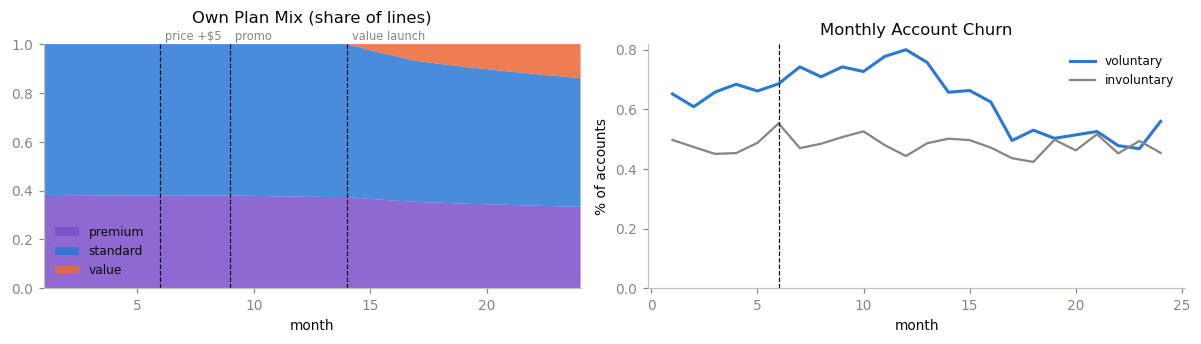

In [12]:
# Plot: Plan Mix & Churn over Time
own_lines = usage_panel.groupby(['month', 'plan'])['lines'].sum().unstack().reindex(columns = ['premium', 'standard', 'value']).fillna(0)
own_accounts = usage_panel.groupby('month').size()
voluntary = events_true[events_true['from_alt'].isin(ALTS[:4]) & ~events_true['to_alt'].isin(ALTS[:4]) & ~events_true['involuntary']]
involuntary = events_true[events_true['involuntary']]

fig, axes = plt.subplots(1, 2, figsize = (11, 3.2))
shares = own_lines.div(own_lines.sum(axis = 1), axis = 0)
axes[0].stackplot(shares.index, shares.T.values, labels = shares.columns, colors = ['#7b4fc9', ACCENT, ACCENT2], alpha = 0.85)
for m, label in [(PRICE_CHANGE_MONTH, 'price +$5'), (PROMO_MONTHS[0], 'promo'), (VALUE_LAUNCH_MONTH, 'value launch')]:
    axes[0].axvline(m, color = INK, linewidth = 0.8, linestyle = '--')
    axes[0].text(m + 0.2, 1.02, label, fontsize = 7.5, color = MUTED)
axes[0].set_ylim(0, 1)
axes[0].set_xlim(1, N_MONTHS)
axes[0].set_title('Own Plan Mix (share of lines)', pad = 14)
axes[0].set_xlabel('month')
axes[0].legend(frameon = False, fontsize = 8, loc = 'lower left')

churn = pd.DataFrame({
    'voluntary': voluntary.groupby('month').size(),
    'involuntary': involuntary.groupby('month').size(),
}).reindex(own_accounts.index).fillna(0).div(own_accounts, axis = 0)
axes[1].plot(churn.index, churn['voluntary'] * 100, color = ACCENT, linewidth = 2, label = 'voluntary')
axes[1].plot(churn.index, churn['involuntary'] * 100, color = MUTED, linewidth = 1.5, label = 'involuntary')
axes[1].axvline(PRICE_CHANGE_MONTH, color = INK, linewidth = 0.8, linestyle = '--')
axes[1].set_ylim(bottom = 0)
axes[1].set_title('Monthly Account Churn')
axes[1].set_ylabel('% of accounts')
axes[1].set_xlabel('month')
axes[1].legend(frameon = False, fontsize = 8)

plt.tight_layout()
plt.show()

## 9 · Conjoint

**Purpose:** Simulates a choice-based conjoint: 4,000 respondents each see 10 randomized tasks and 2 fixed holdout tasks, each with three hypothetical plans plus the option to keep their current plan. This is the only source of variation in features independent of price, and the only way to learn about a plan nobody has seen. It is deliberately biased the way real stated-preference data is, so the modeling notebook has to reconcile it with the revealed choices.

**Design Notes:**

1. Sample: 75% current customers and 25% competitor or outside households recruited through a panel vendor
  - Response propensity is higher for Family Anchor and Premium Convenience households, so the raw sample over-represents them and must be reweighted
  - Non-customers have no usage panel; they report usage, with typical under-reporting (about 14% low on average) and noise
2. Profiles are unbranded; each attribute level is drawn at random per profile
3. Tasks 11–12 are fixed holdouts, identical for every respondent and flagged is_holdout
  - Holdout 1 mirrors the real ladder: an `essentials`-like, a `standard`-like, and a `premium`-like profile
  - Holdout 2 spans a cheaper range
  - Excluded from estimation, then used to check whether stated-preference models predict out of sample
4. Deliberate hypothetical bias
  - Price coefficient attenuated to 70% of its true value: respondents say they care less about price than they act
  - Overall utility scale 0.75: stated choices are noisier than real ones
  - Keep-current utility lowered by 0.5: respondents over-select new options in surveys
5. The true values of all three distortions are exported, so the RP–SP scale estimate can be scored

**Real-World Estimation:**

1. Fielded through an online panel with screener questions for plan, lines, and usage
2. Part-worths estimated with hierarchical Bayes; distortions corrected through joint estimation with revealed choices and holdout tasks

**Observations:**

- _To be written once parameters are final._

In [13]:
# Simulate Conjoint
CONJOINT_LEVELS = {
    'price_per_line': [35.0, 45.0, 55.0, 65.0, 75.0, 85.0, 95.0],
    'data_gb': [10.0, 20.0, 50.0, np.inf],
    'hotspot_gb': [0.0, 5.0, 15.0, 50.0],
    'stream_tier': [0, 1, 2],
    'roaming_tier': [0, 1, 2],
    'perks_value': [0.0, 8.0, 12.0],
}
RESPONSE_PROPENSITY = np.array([0.8, 0.9, 1.2, 1.3])


def profile_utility(hid, profiles, price_factor, include_price = True):

    t = TASTE_ARRAYS
    mu = HH['usage_mu'][hid]
    tier = profiles['roaming_tier']

    return (
        t['b_price'][hid] * price_factor * profiles['price_per_line'] +
        t['b_throttle'][hid] * throttled_gb(mu, profiles['data_gb']) +
        t['b_hotspot'][hid] * np.maximum(HH['hotspot_need_gb'][hid] - profiles['hotspot_gb'], 0.0) +
        t['b_stream'][hid] * profiles['stream_tier'] +
        t['b_roam'][hid] * (HH['intl_days_rate'][hid] * (tier < 2) + HH['na_days_rate'][hid] * (tier < 1)) +
        t['b_perks'][hid] * profiles['perks_value']
    )


def simulate_conjoint(state, price, rng):

    weight = RESPONSE_PROPENSITY[tastes['class_id'].to_numpy()]
    customers = np.flatnonzero(IS_OWN[state])
    others = np.flatnonzero(~IS_OWN[state])
    n_other = int(N_RESPONDENTS * NONCUSTOMER_SHARE)

    respondents = np.r_[
        rng.choice(customers, N_RESPONDENTS - n_other, replace = False, p = weight[customers] / weight[customers].sum()),
        rng.choice(others, n_other, replace = False, p = weight[others] / weight[others].sum()),
    ]

    n_resp = len(respondents)
    n_all = N_TASKS + N_HOLDOUT_TASKS
    holdouts = np.array(CONJOINT_HOLDOUTS, dtype = float)
    profiles = {
        k: np.concatenate([
            rng.choice(levels, size = (n_resp, N_TASKS, N_PROFILES)).astype(float),
            np.broadcast_to(holdouts[:, :, i], (n_resp, N_HOLDOUT_TASKS, N_PROFILES)),
        ], axis = 1).ravel()
        for i, (k, levels) in enumerate(CONJOINT_LEVELS.items())
    }

    hid = np.repeat(respondents, n_all * N_PROFILES)
    V_profiles = SP_SCALE * profile_utility(hid, profiles, SP_PRICE_ATTENUATION).reshape(-1, N_PROFILES)

    current = state[respondents]
    t = TASTE_ARRAYS
    current_features = {
        'price_per_line': price[respondents, current],
        'data_gb': CATALOG['data_gb'].to_numpy()[current],
        'hotspot_gb': CATALOG['hotspot_gb'].to_numpy()[current],
        'stream_tier': CATALOG['stream_tier'].to_numpy()[current].astype(float),
        'roaming_tier': CATALOG['roaming_tier'].to_numpy()[current].astype(float),
        'perks_value': CATALOG['perks_value'].to_numpy()[current],
    }
    V_current = (
        profile_utility(respondents, current_features, SP_PRICE_ATTENUATION) +
        np.where(CARRIER[current] == 'competitor', t['asc_competitor'][respondents], 0.0) +
        np.where(CARRIER[current] == 'outside', t['asc_outside'][respondents], 0.0) +
        0.5 * t['inertia'][respondents] + SP_KEEP_CURRENT_BIAS
    )
    V_current = SP_SCALE * np.repeat(V_current, n_all)

    V = np.column_stack([V_profiles, V_current])
    chosen = (V + rng.gumbel(size = V.shape)).argmax(axis = 1)

    long = pd.DataFrame({
        'respondent_id': np.repeat(respondents, n_all * (N_PROFILES + 1)),
        'task': np.tile(np.repeat(np.arange(1, n_all + 1), N_PROFILES + 1), n_resp),
        'option': np.tile(['A', 'B', 'C', 'keep_current'], n_resp * n_all),
    })
    long['is_holdout'] = long['task'] > N_TASKS
    for k in CONJOINT_LEVELS:
        stacked = np.column_stack([profiles[k].reshape(-1, N_PROFILES), np.repeat(current_features[k], n_all)])
        long[k] = stacked.ravel()
    long['price_per_line'] = long['price_per_line'].round(2)
    long['chosen'] = (np.arange(N_PROFILES + 1)[None, :] == chosen[:, None]).ravel()

    h = households.set_index('household_id').loc[respondents]
    respondent_table = pd.DataFrame({
        'respondent_id': respondents,
        'is_customer': IS_OWN[current],
        'current_carrier': CARRIER[current],
        'current_plan': np.where(IS_OWN[current], np.array(ALTS)[current], CARRIER[current]),
        'lines': h['lines'].to_numpy(),
        'age_band': h['age_band'].to_numpy(),
        'zip_income_tier': h['zip_income_tier'].to_numpy(),
        'device_tier': h['device_tier'].to_numpy(),
        'market_id': h['market_id'].to_numpy(),
        'reported_gb_per_line': (np.exp(HH['usage_mu'][respondents]) * np.exp(rng.normal(-0.15, 0.45, size = len(respondents)))).round(1),
        'reported_intl_trips_per_year': rng.poisson(HH['intl_days_rate'][respondents] * 12 / 4),
    })

    return long, respondent_table

conjoint, conjoint_respondents = simulate_conjoint(state_m24, history_portfolio(N_MONTHS, None)['price'], RNG)
display(
    conjoint[conjoint['chosen']].groupby(['is_holdout', 'option']).size()
        .div(conjoint[conjoint['chosen']].groupby('is_holdout').size(), level = 'is_holdout').unstack('is_holdout').round(3)
        .rename(columns = {False: 'randomized tasks', True: 'holdout tasks'}).rename_axis(None).rename_axis(None, axis = 1)
)

,randomized tasks,holdout tasks
A,0.216,0.282
B,0.218,0.193
C,0.215,0.161
keep_current,0.350,0.365


## 10 · Counterfactual Launch

**Purpose:** Draws the launch itself: 12 months after month 24, once with the existing portfolio (World A) and once with `essentials` added (World B), across 9 prices × 4 bundles × 3 eligibility rules. Every world uses the same month-seeded draws, so the difference between A and B for any household is caused by the launch alone. This is the answer key the modeling notebook's forecast is scored against.

**Design Notes:**

1. Bundles vary what `essentials` gives up: base `lean` (20 GB, no hotspot, SD), plus a 5 GB hotspot, a 30 GB cap, or HD streaming
2. Eligibility rules are the fences
  - `open`: anyone, with the multi-line discount
  - `no_multiline_discount`: anyone, but every line at list price
  - `new_lines_only`: only households not already with the carrier
3. World B adds launch marketing in the first three months, scaled by each market's randomized intensity (quiet / standard / heavy); this raises consideration, so a launch can stir switching to other plans as well as to `essentials`
4. Source of volume per household = (World A state at month 36, World B state at month 36); saved churners appear as A = competitor or outside, B = own
5. Margin is accumulated over the 12 months in both worlds, so net contribution is B − A, including retention and acquisition effects
6. Outputs: per-household results across the price grid for the reference bundle and eligibility, plus aggregated transition counts and margin for every configuration

**Real-World Estimation:**

1. None of this is observable; the closest real equivalent is a staggered or market-randomized launch with holdout markets, read by difference-in-differences
2. Even then only the aggregate difference is recovered, never which household would have done what

**Observations:**

- _To be written once parameters are final._

In [14]:
# Simulate Counterfactual Launch
HORIZON = range(N_MONTHS + 1, N_MONTHS + N_HORIZON + 1)


def launch_portfolio(catalog = None, eligibility = 'open', surplus = None):

    list_price, available = history_prices(N_MONTHS)
    world_b = catalog is not None
    catalog = catalog if world_b else CATALOG
    surplus = surplus if world_b else SURPLUS_BASE
    available[A['essentials']] = world_b
    price = effective_prices(catalog['list_price'].to_numpy(), catalog)

    def portfolio(month, state):

        avail = np.broadcast_to(available, (N_HOUSEHOLDS, len(ALTS))).copy()
        if world_b and eligibility == 'new_lines_only':
            avail[IS_OWN[state], A['essentials']] = False

        in_window = world_b and month < N_MONTHS + 1 + LAUNCH_WINDOW
        return {
            'catalog': catalog, 'surplus': surplus, 'price': price, 'available': avail,
            'consider_boost': CONSIDER['launch_marketing'] * HH['launch_intensity'] * in_window,
        }

    return portfolio

world_a = simulate(state_m24, throttled_m24, HORIZON, launch_portfolio())

grid_rows, reference_rows = [], []
for bundle in ESSENTIALS_BUNDLES:
    bundle_surplus = feature_surplus(demand, catalog_for(bundle))
    for eligibility in ELIGIBILITY:
        for price in ESSENTIALS_PRICES:
            catalog = catalog_for(bundle, price, eligibility)
            world_b = simulate(state_m24, throttled_m24, HORIZON, launch_portfolio(catalog, eligibility, bundle_surplus))

            pairs = pd.DataFrame({
                'state_a': np.array(ALTS)[world_a['state']], 'state_b': np.array(ALTS)[world_b['state']],
                'lines': HH['lines'], 'margin_a': world_a['margin'], 'margin_b': world_b['margin'],
            })
            agg = pairs.groupby(['state_a', 'state_b']).agg(
                households = ('lines', 'size'), lines = ('lines', 'sum'),
                margin_a = ('margin_a', 'sum'), margin_b = ('margin_b', 'sum'),
            ).reset_index()
            grid_rows.append(agg.assign(bundle = bundle, eligibility = eligibility, essentials_price = price))

            if bundle == 'lean' and eligibility == 'open':
                reference_rows.append(pairs.assign(
                    household_id = np.arange(N_HOUSEHOLDS), essentials_price = price,
                    first_essentials_month = world_b['first_essentials'],
                ))

counterfactual_grid = pd.concat(grid_rows, ignore_index = True)
counterfactual_launch = pd.concat(reference_rows, ignore_index = True)


def launch_summary(grid):

    g = grid.copy()
    g['own_a'] = g['state_a'].isin(ALTS[:4])
    on_essentials = g[g['state_b'] == 'essentials']
    own_b = g[g['state_b'].isin(ALTS[:4])]
    keys = ['bundle', 'eligibility', 'essentials_price']

    return pd.DataFrame({
        'essentials households': on_essentials.groupby(keys)['households'].sum(),
        'take rate': on_essentials.groupby(keys)['households'].sum() / own_b.groupby(keys)['households'].sum(),
        'from premium/standard': on_essentials[on_essentials['state_a'].isin(['premium', 'standard'])].groupby(keys)['households'].sum()
            / on_essentials.groupby(keys)['households'].sum(),
        'from value': on_essentials[on_essentials['state_a'].eq('value')].groupby(keys)['households'].sum()
            / on_essentials.groupby(keys)['households'].sum(),
        'from outside the carrier': on_essentials[~on_essentials['own_a']].groupby(keys)['households'].sum()
            / on_essentials.groupby(keys)['households'].sum(),
        'net margin (12 mo, $M)': (g.groupby(keys)['margin_b'].sum() - g.groupby(keys)['margin_a'].sum()) / 1e6,
    }).fillna(0)

summary = launch_summary(counterfactual_grid)
display(summary.xs(('lean', 'open'), level = ['bundle', 'eligibility']).round(3))

,essentials households,take rate,from premium/standard,from value,from outside the carrier,"net margin (12 mo, $M)"
essentials_price,,,,,,
35.0,13334,0.277,0.198,0.416,0.385,-1.444
37.5,11570,0.245,0.197,0.443,0.359,-0.980
40.0,9833,0.212,0.195,0.469,0.337,-0.608
42.5,8141,0.179,0.191,0.501,0.308,-0.310
45.0,6529,0.145,0.189,0.527,0.283,-0.090
47.5,5026,0.113,0.188,0.557,0.256,0.063
50.0,3768,0.086,0.191,0.576,0.233,0.155
52.5,2752,0.063,0.194,0.597,0.209,0.204
55.0,1952,0.045,0.199,0.607,0.195,0.226


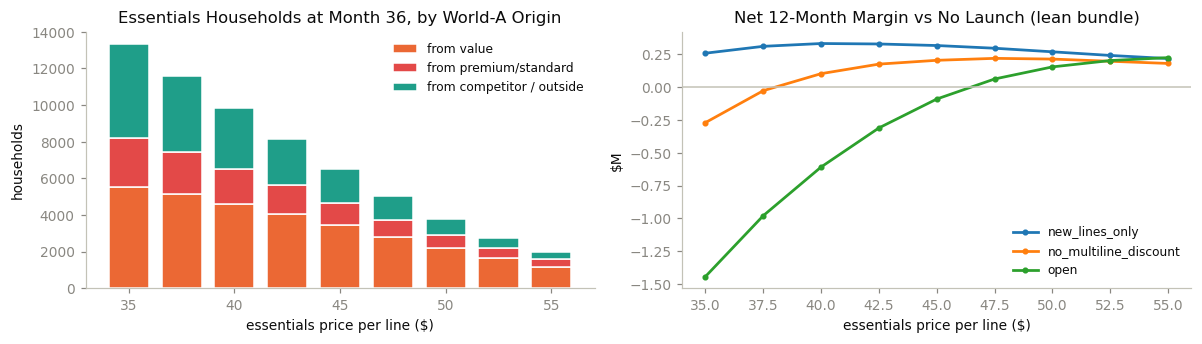

In [15]:
# Plot: Source of Volume & Net Margin across Price
ref = summary.xs(('lean', 'open'), level = ['bundle', 'eligibility'])
fig, axes = plt.subplots(1, 2, figsize = (11, 3.2))

x = ref.index.to_numpy()
parts = [('from value', ACCENT2, 'from value'), ('from premium/standard', RED, 'from premium/standard'), ('from outside the carrier', '#1f9e89', 'from competitor / outside')]
bottom = np.zeros(len(x))
for col, color, label in parts:
    vals = ref[col].to_numpy() * ref['essentials households'].to_numpy()
    axes[0].bar(x, vals, bottom = bottom, width = 1.9, color = color, edgecolor = SURFACE, label = label)
    bottom += vals
axes[0].set_title('Essentials Households at Month 36, by World-A Origin')
axes[0].set_xlabel('essentials price per line ($)')
axes[0].set_ylabel('households')
axes[0].legend(frameon = False, fontsize = 8)

for (bundle, eligibility), grp in summary.groupby(level = ['bundle', 'eligibility']):
    if bundle != 'lean':
        continue
    s = grp.droplevel(['bundle', 'eligibility'])['net margin (12 mo, $M)']
    axes[1].plot(s.index, s.values, marker = 'o', markersize = 3, linewidth = 1.8, label = eligibility)
axes[1].axhline(0, color = BASELINE, linewidth = 1)
axes[1].set_title('Net 12-Month Margin vs No Launch (lean bundle)')
axes[1].set_xlabel('essentials price per line ($)')
axes[1].set_ylabel('$M')
axes[1].legend(frameon = False, fontsize = 8)

plt.tight_layout()
plt.show()

## 11 · Sanity Checks

**Purpose:** Confirms the parameters produced a plausible market and hit the targets the case study depends on, since anything downstream inherits whatever the generator got wrong.

**Design Notes:**

1. Any failure below → parameters in §2, §3, or §7 need tuning before anything is worth fitting
2. Market checks: carrier share, monthly churn, plan mix, and how often caps bind
  - The `value` launch should reduce voluntary churn, but only partly; a near-total drop would mean every churner leaves over price
3. Structure checks: error sampler accuracy, and whether the nested structure draws materially less of `essentials` volume from `premium` and `standard` than a flat logit with identical utilities
  - Compared on the same utilities, including inertia and switching cost, so the gap is the nesting alone
  - A naive comparison against population shares would be misleading: switching costs alone make any new plan draw heavily from the carrier's existing base
4. Launch checks: `essentials` take rate and origin mix at the reference configuration (&#36;45, lean, open)

**Observations:**

- _To be written once parameters are final._

In [16]:
# Run Sanity Checks
own_m24 = IS_OWN[state_m24]
plan_lines = pd.Series(HH['lines'][own_m24]).groupby(np.array(ALTS)[state_m24[own_m24]]).sum()
plan_lines = plan_lines / plan_lines.sum()

def expected_origin(bundle = 'lean', price = REFERENCE_PRICE):

    catalog = catalog_for(bundle, price)
    everyone = np.arange(N_HOUSEHOLDS)
    V = systematic_utility(everyone, effective_prices(catalog['list_price'].to_numpy(), catalog), feature_surplus(demand, catalog), current = state_m24)
    V_without = V.copy()
    V_without[:, A['essentials']] = -np.inf

    nested = (nested_logit_probs(V_without) - nested_logit_probs(V)).clip(min = 0).sum(axis = 0)
    flat = (softmax(V_without, axis = 1) - softmax(V, axis = 1)).clip(min = 0).sum(axis = 0)

    return pd.DataFrame({'nested': nested / nested.sum(), 'flat logit': flat / flat.sum()}, index = ALTS).drop(index = 'essentials')

origin = expected_origin()

ref_row = summary.loc[('lean', 'open', REFERENCE_PRICE)]
monthly_churn = (churn['voluntary'] + churn['involuntary']).mean()
save_ratio = churn.loc[VALUE_LAUNCH_MONTH + LAUNCH_WINDOW:, 'voluntary'].mean() / churn.loc[:VALUE_LAUNCH_MONTH - 1, 'voluntary'].mean()

checks = pd.DataFrame([
    ('carrier share of households, month 0', IS_OWN[state0].mean(), 0.55, 0.70),
    ('monthly account churn', monthly_churn, 0.008, 0.014),
    ('voluntary churn after value launch / before', save_ratio, 0.60, 0.90),
    ('premium share of lines, month 24', plan_lines.get('premium', 0), 0.25, 0.40),
    ('standard share of lines, month 24', plan_lines.get('standard', 0), 0.40, 0.65),
    ('value share of lines, month 24', plan_lines.get('value', 0), 0.06, 0.20),
    ('throttled share of account-months', usage_panel['throttled'].mean(), 0.04, 0.15),
    ('error sampler max share gap', np.abs(simulated - nested_logit_probs(V_test[:1])[0]).max(), 0.0, 0.005),
    ('nested / flat share from premium/standard', origin.loc[['premium', 'standard'], 'nested'].sum() / origin.loc[['premium', 'standard'], 'flat logit'].sum(), 0.0, 0.70),
    ('essentials take rate at reference', ref_row['take rate'], 0.09, 0.15),
    ('essentials share from premium/standard', ref_row['from premium/standard'], 0.0, 0.35),
], columns = ['check', 'value', 'low', 'high'])
checks['pass'] = checks['value'].between(checks['low'], checks['high'])
display(checks.round(4).set_index('check').rename_axis(None))
display(origin.round(3).rename_axis(None).style.set_caption('Expected origin of essentials, same utilities, one choice occasion'))

,value,low,high,pass
"carrier share of households, month 0",0.5509,0.550,0.700,True
monthly account churn,0.0111,0.008,0.014,True
voluntary churn after value launch / before,0.7192,0.600,0.900,True
"premium share of lines, month 24",0.3303,0.250,0.400,True
"standard share of lines, month 24",0.5208,0.400,0.650,True
"value share of lines, month 24",0.1489,0.060,0.200,True
throttled share of account-months,0.0464,0.040,0.150,True
error sampler max share gap,0.0007,0.000,0.005,True
nested / flat share from premium/standard,0.5781,0.000,0.700,True
essentials take rate at reference,0.1452,0.090,0.150,True


,nested,flat logit
premium,0.050000,0.097000
standard,0.150000,0.248000
value,0.573000,0.275000
comp_premium,0.010000,0.026000
comp_value,0.110000,0.182000
outside,0.107000,0.173000


## 12 · Ground Truth & Export

**Purpose:** Writes the model-facing tables and the withheld answer key as separate files, so later notebooks can be scored on whether they recover the true classes, part-worths, and launch outcome rather than just how well they fit.

**Design Notes:**

1. Model-facing tables contain only what a carrier would hold
  - accounts: households that were customers at any point in months 1–24, with observable fields only
  - usage_panel, plan_events, plan_catalog, price_history, markets (launch_intensity included, since it is the carrier's own plan)
  - conjoint_responses, conjoint_respondents
2. plan_events relabels destinations and origins the way a carrier sees them: competitor plans become `competitor`, and `outside` becomes `outside` for churn and `new` for gross adds
3. Withheld tables
  - ground_truth: class, individual part-worths, true demand parameters, and the true plan at months 0, 13, 24
  - true_plan_events: exact competitor plans behind every port-in and port-out
  - value_launch_counterfactual: month-24 state with and without the `value` launch, for the back-test
  - counterfactual_launch (reference configuration, all prices) and counterfactual_grid (all configurations)
  - generator_parameters: nesting λ's and conjoint distortions

**Observations:**

- _To be written once parameters are final._

In [17]:
# Export Ground Truth
ever_customer = np.flatnonzero(np.isin(np.arange(N_HOUSEHOLDS), usage_panel['account_id'].unique()))
first_seen = usage_panel.groupby('account_id')['month'].min()

model_accounts = households.set_index('household_id').loc[ever_customer].reset_index().rename(columns = {'household_id': 'account_id'})
model_accounts['first_month_observed'] = first_seen.reindex(model_accounts['account_id']).to_numpy()
model_accounts['tenure_at_first_month'] = np.where(model_accounts['first_month_observed'] == 1, model_accounts['tenure_months'], 0)
model_accounts = model_accounts.drop(columns = ['tenure_months', 'competitive_intensity'])

own_names = set(ALTS[:4])
plan_events = events_true.rename(columns = {'household_id': 'account_id'}).copy()
plan_events['event'] = np.select(
    [plan_events['from_alt'].isin(own_names) & plan_events['to_alt'].isin(own_names),
     plan_events['from_alt'].isin(own_names)],
    ['migration', 'churn'], 'gross_add',
)
plan_events['from_plan'] = np.where(plan_events['from_alt'].isin(own_names), plan_events['from_alt'],
                                    np.where(plan_events['from_alt'].eq('outside'), 'new', 'competitor'))
plan_events['to_plan'] = np.where(plan_events['to_alt'].isin(own_names), plan_events['to_alt'],
                                  np.where(plan_events['to_alt'].eq('outside'), 'outside', 'competitor'))
plan_events = plan_events.loc[plan_events['from_alt'].isin(own_names) | plan_events['to_alt'].isin(own_names),
                              ['account_id', 'month', 'event', 'from_plan', 'to_plan', 'involuntary']]

ground_truth = tastes.merge(demand, on = 'household_id')
ground_truth['plan_month_0'] = np.array(ALTS)[state0]
ground_truth['plan_month_13'] = np.array(ALTS)[first_half['state']]
ground_truth['plan_month_24'] = np.array(ALTS)[state_m24]

value_launch_counterfactual = pd.DataFrame({
    'household_id': np.arange(N_HOUSEHOLDS),
    'state_m24_actual': np.array(ALTS)[second_half['state']],
    'state_m24_no_value': np.array(ALTS)[no_value['state']],
    'margin_actual': second_half['margin'].round(2),
    'margin_no_value': no_value['margin'].round(2),
})

generator_parameters = pd.DataFrame([
    ('lambda_premium_tier', LAMBDA_PREMIUM_TIER), ('lambda_value_tier', LAMBDA_VALUE_TIER), ('lambda_value_pair', LAMBDA_VALUE_PAIR),
    ('sp_price_attenuation', SP_PRICE_ATTENUATION), ('sp_scale', SP_SCALE), ('sp_keep_current_bias', SP_KEEP_CURRENT_BIAS),
    ('throttled_use_rate', THROTTLED_USE_RATE), ('base_churn', BASE_CHURN), ('service_churn', SERVICE_CHURN),
], columns = ['parameter', 'value'])

plan_catalog = CATALOG.drop(index = 'essentials').rename_axis('plan').reset_index()


def save(df, name):

    path = DATA / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

paths = [save(df, name) for df, name in [
    (model_accounts, 'accounts'), (usage_panel, 'usage_panel'), (plan_events, 'plan_events'),
    (plan_catalog, 'plan_catalog'), (price_history, 'price_history'), (markets, 'markets'),
    (conjoint, 'conjoint_responses'), (conjoint_respondents, 'conjoint_respondents'),
    (ground_truth, 'ground_truth'), (events_true, 'true_plan_events'),
    (value_launch_counterfactual, 'value_launch_counterfactual'),
    (counterfactual_launch, 'counterfactual_launch'), (counterfactual_grid, 'counterfactual_grid'),
    (generator_parameters, 'generator_parameters'),
]]

print(f'Written to: {DATA.resolve()}')
display(pd.DataFrame({'size (MB)': [round(p.stat().st_size / 1e6, 2) for p in paths]},
                     index = [p.name for p in paths]).rename_axis(None))

Written to: /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/rate-plan-cannibalization/data/synthetic


,size (MB)
accounts.parquet,0.48
usage_panel.parquet,10.45
plan_events.parquet,0.20
plan_catalog.parquet,0.01
price_history.parquet,0.00
markets.parquet,0.00
conjoint_responses.parquet,0.46
conjoint_respondents.parquet,0.05
ground_truth.parquet,11.57
true_plan_events.parquet,0.22


---
# Part 2 · Validating the Synthetic Data

1. Confirm the generated market behaves like a plausible wireless population before fitting anything
2. Confirm each structure the modeling notebook is meant to find is actually present, and not trivially easy to find
3. Not exploratory in the usual sense: the generating process is known, so every check either validates the generator or documents a difficulty the modeling notebook must handle
4. Six questions:
  - Does the panel look real? Plan mix, bills, usage, and margin concentration in plausible ranges
  - Are the taste classes visible in observable data, but not perfectly?
  - How much demand does censoring by the current plan hide?
  - Is there enough price variation to estimate a response from revealed choices alone, and is the promotion confounded as designed?
  - Does the carrier's own view of the `value` launch differ from its true incremental effect?
  - Is the conjoint biased in the designed directions, and does the launch answer key hold together?
5. Failure in the first four → fix parameters in Part 1; failure in the last two → the case study's central comparison has nothing to show
6. Reuses Part 1's in-memory objects; accounts is rebound to model_accounts to match what downstream notebooks load from disk

In [18]:
# Reuse Part 1 Objects
accounts = model_accounts
truth = ground_truth.set_index('household_id')

print(f'{len(accounts):,} accounts · {len(usage_panel):,} account-months · {len(plan_events):,} plan events · {conjoint_respondents.shape[0]:,} conjoint respondents')

50,927 accounts · 1,017,839 account-months · 30,646 plan events · 4,000 conjoint respondents


---
## 1 · Panel Realism

**Purpose:** Confirms the carrier's own data looks like a real postpaid base: bills, usage by plan, and how concentrated margin is.

**Design Notes:**

1. Observed usage should rise sharply by plan tier, since heavier users self-select up
2. Margin should be concentrated: multi-line premium households carry a disproportionate share
3. If usage were flat across plans, plan choice would carry no information about demand, and the surplus mechanism in Part 1 §5 would be doing nothing

**Expected Characteristics:**

- Median observed GB per line ordered value < standard < premium
- Monthly bills right-skewed, driven by line count
- Top decile of accounts carrying well over 10% of margin

**Observations:**

- _To be written once parameters are final._

,accounts,lines_per_account,median_gb_per_line,p90_gb_per_line,median_bill,throttled,margin_per_account
value,6078,2.30,10.43,21.82,82.50,0.34,45.99
standard,22058,2.39,13.67,40.07,115.50,0.06,77.40
premium,14419,2.31,16.42,58.28,156.75,0.00,98.04


Top decile of accounts carries 22.1% of 24-month margin


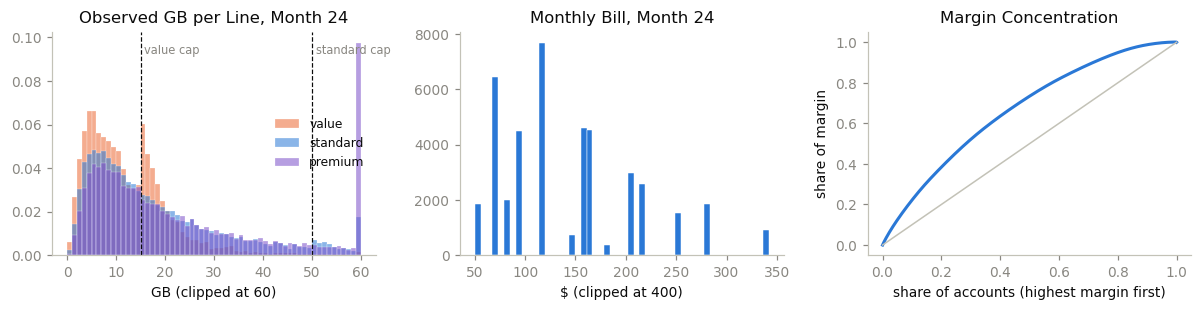

In [19]:
# Check Panel Realism
last_month = usage_panel[usage_panel['month'] == N_MONTHS]
plan_order = ['value', 'standard', 'premium']

by_plan = last_month.groupby('plan').agg(
    accounts = ('account_id', 'size'),
    lines_per_account = ('lines', 'mean'),
    median_gb_per_line = ('gb_per_line', 'median'),
    p90_gb_per_line = ('gb_per_line', lambda x: x.quantile(0.9)),
    median_bill = ('bill', 'median'),
    throttled = ('throttled', 'mean'),
    margin_per_account = ('margin', 'mean'),
).reindex(plan_order)
display(by_plan.round(2).rename_axis(None))

margin_by_account = usage_panel.groupby('account_id')['margin'].sum().sort_values(ascending = False)
top_decile_share = margin_by_account.head(len(margin_by_account) // 10).sum() / margin_by_account.sum()
print(f'Top decile of accounts carries {top_decile_share:.1%} of 24-month margin')

fig, axes = plt.subplots(1, 3, figsize = (11, 2.9))
bins = np.linspace(0, 60, 61)
for plan, color in zip(plan_order, [ACCENT2, ACCENT, '#7b4fc9']):
    vals = last_month.loc[last_month['plan'] == plan, 'gb_per_line']
    axes[0].hist(vals.clip(upper = 60), bins = bins, density = True, alpha = 0.55, color = color, edgecolor = SURFACE, linewidth = 0.3, label = plan)
for cap, label in [(15, 'value cap'), (50, 'standard cap')]:
    axes[0].axvline(cap, color = INK, linewidth = 0.8, linestyle = '--')
    axes[0].text(cap + 0.8, axes[0].get_ylim()[1] * 0.9, label, fontsize = 7.5, color = MUTED)
axes[0].set_title('Observed GB per Line, Month 24')
axes[0].set_xlabel('GB (clipped at 60)')
axes[0].legend(frameon = False, fontsize = 8, loc = 'center right')

axes[1].hist(last_month['bill'].clip(upper = 400), bins = 50, color = ACCENT, edgecolor = SURFACE, linewidth = 0.3)
axes[1].set_title('Monthly Bill, Month 24')
axes[1].set_xlabel('$ (clipped at 400)')

cum = margin_by_account.cumsum() / margin_by_account.sum()
axes[2].plot(np.arange(1, len(cum) + 1) / len(cum), cum.to_numpy(), color = ACCENT, linewidth = 2)
axes[2].plot([0, 1], [0, 1], color = BASELINE, linewidth = 1)
axes[2].set_title('Margin Concentration')
axes[2].set_xlabel('share of accounts (highest margin first)')
axes[2].set_ylabel('share of margin')

plt.tight_layout()
plt.show()

---
## 2 · Class Differentiation

**Purpose:** Confirms the latent classes leave a visible trace in observable data, and measures how well they can be predicted from it. This sets the ceiling for any segmentation the modeling notebook builds.

**Design Notes:**

1. Profiles: each class should differ on the observables that drove membership and on observed behavior
2. Predictability: a multinomial logistic regression on observables and 24-month usage summaries, scored on held-out accounts
  - Near the majority-class baseline → classes are invisible, and a latent class model has nothing to anchor membership to
  - Near 100% → classes are just a relabelling of observables, and the latent class model is unnecessary
  - Somewhere in between is the intended difficulty
3. Customers only: this is what the carrier can actually fit on

**Expected Characteristics:**

- Family Anchors with clearly more lines; Premium Convenience with flagship devices, higher income, and more roaming; Data-Hungry with far higher usage
- Held-out accuracy well above baseline but well short of perfect

**Observations:**

- _To be written once parameters are final._

In [20]:
# Check Class Differentiation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

behavior = usage_panel.groupby('account_id').agg(
    mean_gb = ('gb_per_line', 'mean'), max_gb = ('gb_per_line', 'max'), hotspot_gb = ('hotspot_gb', 'mean'),
    intl_days = ('intl_roam_days', 'mean'), na_days = ('na_roam_days', 'mean'),
    throttled = ('throttled', 'mean'), months = ('month', 'size'), last_plan = ('plan', 'last'),
)
profile = accounts.set_index('account_id').join(behavior)
profile['latent_class'] = truth.loc[profile.index, 'latent_class']

display(profile.groupby('latent_class').agg(
    accounts = ('lines', 'size'), lines = ('lines', 'mean'),
    flagship = ('device_tier', lambda x: x.eq('flagship').mean()), high_income = ('zip_income_tier', lambda x: x.eq('high').mean()),
    age_18_29 = ('age_band', lambda x: x.eq('18-29').mean()), mean_gb = ('mean_gb', 'mean'),
    hotspot_gb = ('hotspot_gb', 'mean'), intl_days = ('intl_days', 'mean'), on_premium = ('last_plan', lambda x: x.eq('premium').mean()),
).reindex(CLASSES).round(2).rename_axis(None))

X = pd.get_dummies(
    profile[['lines', 'age_band', 'zip_income_tier', 'device_tier', 'autopay', 'last_plan']], drop_first = True
).assign(
    log_mean_gb = np.log1p(profile['mean_gb']), log_max_gb = np.log1p(profile['max_gb']),
    hotspot_gb = profile['hotspot_gb'], intl_days = profile['intl_days'], na_days = profile['na_days'], throttled = profile['throttled'],
).astype(float)
y = profile['latent_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = SEED, stratify = y)
clf = LogisticRegression(max_iter = 2000).fit((X_train - X_train.mean()) / X_train.std(), y_train)
accuracy = (clf.predict((X_test - X_train.mean()) / X_train.std()) == y_test).mean()
baseline = y_test.value_counts(normalize = True).max()
print(f'Held-out class accuracy: {accuracy:.1%} (majority-class baseline {baseline:.1%})')

,accounts,lines,flagship,high_income,age_18_29,mean_gb,hotspot_gb,intl_days,on_premium
budget_constrained,9962,2.29,0.11,0.10,0.13,10.30,0.74,0.10,0.09
data_hungry,14112,2.03,0.38,0.22,0.37,29.03,5.45,0.30,0.26
family_anchor,10814,3.06,0.23,0.19,0.15,16.30,2.18,0.30,0.20
premium_convenience,16039,2.15,0.56,0.50,0.17,19.83,4.21,0.92,0.63


Held-out class accuracy: 66.5% (majority-class baseline 31.5%)


---
## 3 · Usage Censoring

**Purpose:** Measures how much true demand the observed usage hides, by plan. The modeling notebook's feature surplus is built from observed usage, so this is the size of the bias it must correct.

**Design Notes:**

1. Latent demand is recomputed from the ground truth using the same month-seeded draws as the history, so each account-month's true demand lines up exactly with its observed usage
2. Hidden share = (demand − observed) / demand, summed over account-months
3. Concentrated on `value` by design: the tightest cap binds most often
4. Above the cap the observed/demand relationship is noisy, not a clean kink, so demand has to be estimated rather than back-calculated

**Expected Characteristics:**

- Near-zero hidden demand on `premium` (no cap)
- Material hidden demand on `value`, and among throttled account-months on any plan

**Observations:**

- _To be written once parameters are final._

,throttled months,hidden share of demand,hidden share when throttled
value,0.345,0.176,0.263
standard,0.055,0.031,0.151
premium,0.000,0.000,NaN


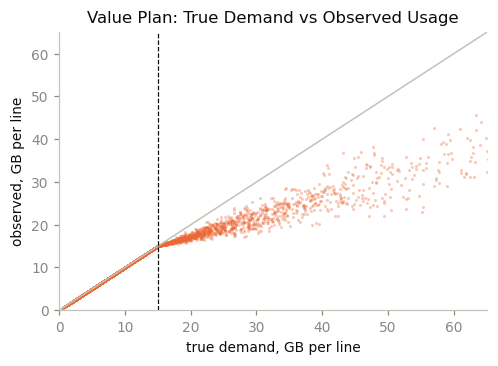

In [21]:
# Check Usage Censoring
demand_rows = []
for month in range(1, N_MONTHS + 1):
    z = month_draws(month)['demand_z']
    ids = usage_panel.loc[usage_panel['month'] == month, 'account_id'].to_numpy()
    demand_rows.append(pd.DataFrame({'account_id': ids, 'month': month, 'demand_gb': np.exp(HH['usage_mu'][ids] + SIGMA_WITHIN * z[ids])}))
censoring = usage_panel[['account_id', 'month', 'plan', 'gb_per_line', 'throttled']].merge(pd.concat(demand_rows), on = ['account_id', 'month'])

hidden = censoring.groupby('plan').apply(
    lambda g: pd.Series({
        'throttled months': g['throttled'].mean(),
        'hidden share of demand': 1 - g['gb_per_line'].sum() / g['demand_gb'].sum(),
        'hidden share when throttled': 1 - g.loc[g['throttled'], 'gb_per_line'].sum() / g.loc[g['throttled'], 'demand_gb'].sum() if g['throttled'].any() else np.nan,
    }), include_groups = False,
).reindex(plan_order).clip(lower = 0)
display(hidden.round(3).rename_axis(None))

sample = censoring[censoring['plan'] == 'value'].sample(4000, random_state = SEED)
fig, ax = plt.subplots(figsize = (4.6, 3.4))
ax.scatter(sample['demand_gb'], sample['gb_per_line'], s = 4, alpha = 0.35, color = ACCENT2, linewidths = 0)
lim = sample['demand_gb'].quantile(0.99)
ax.plot([0, lim], [0, lim], color = BASELINE, linewidth = 1)
ax.axvline(15, color = INK, linewidth = 0.8, linestyle = '--')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_title('Value Plan: True Demand vs Observed Usage')
ax.set_xlabel('true demand, GB per line')
ax.set_ylabel('observed, GB per line')
plt.tight_layout()
plt.show()

---
## 4 · Price Variation & Promotion Confounding

**Purpose:** Confirms the history contains enough price variation to estimate a price response from revealed choices, and that the regional promotion is confounded with competitive intensity as designed.

**Design Notes:**

1. Two sources of variation: the month-6 increase (all markets, all multi-line structures) and the month 9–12 promotion (competitive markets only)
2. Per-line prices also vary across households through line count, but that variation is tied to household type and cannot identify a price response on its own
3. Promotion markets were chosen for their competitive intensity, which independently raises churn
  - A naive comparison of churn in promotion vs other markets mixes the promotion's effect with the market's baseline
  - Within-market comparison (promotion months vs the same markets' other months) separates them

**Expected Characteristics:**

- Visible step in paid price per line at month 6, and a dip in promotion markets in months 9–12
- Promotion markets with higher churn than other markets even during the promotion

**Observations:**

- _To be written once parameters are final._

,other months,promo months
other markets,0.580000,0.730000
promotion markets,0.670000,0.830000


Mean competitive intensity: promotion markets 0.73, other markets 0.34


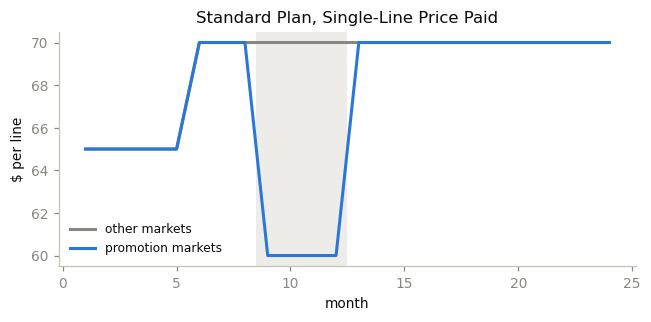

In [22]:
# Check Price Variation & Promotion Confounding
panel = usage_panel.merge(accounts[['account_id', 'market_id']], on = 'account_id').merge(markets[['market_id', 'promo_market', 'competitive_intensity']], on = 'market_id')
std_price = panel[(panel['plan'] == 'standard') & (panel['lines'] == 1)].groupby(['month', 'promo_market'])['price_per_line'].mean().unstack()

leavers = plan_events[(plan_events['event'] == 'churn') & ~plan_events['involuntary']][['account_id', 'month']].assign(churned = True)
panel = panel.merge(leavers, on = ['account_id', 'month'], how = 'left')
panel['churned'] = panel['churned'].eq(True)
panel['period'] = np.where(panel['month'].isin(PROMO_MONTHS), 'promo months', 'other months')

display(
    panel.pivot_table(index = 'promo_market', columns = 'period', values = 'churned', aggfunc = 'mean')
        .rename(index = {True: 'promotion markets', False: 'other markets'}).mul(100).round(2)
        .rename_axis(None).rename_axis(None, axis = 1).style.set_caption('Monthly voluntary churn, %')
)
print(f"Mean competitive intensity: promotion markets {markets.loc[markets['promo_market'], 'competitive_intensity'].mean():.2f}, "
      f"other markets {markets.loc[~markets['promo_market'], 'competitive_intensity'].mean():.2f}")

fig, ax = plt.subplots(figsize = (6, 3))
ax.plot(std_price.index, std_price[False], color = MUTED, linewidth = 2, label = 'other markets')
ax.plot(std_price.index, std_price[True], color = ACCENT, linewidth = 2, label = 'promotion markets')
ax.axvspan(PROMO_MONTHS[0] - 0.5, PROMO_MONTHS[-1] + 0.5, color = GRID, alpha = 0.6, linewidth = 0)
ax.set_title('Standard Plan, Single-Line Price Paid')
ax.set_xlabel('month')
ax.set_ylabel('$ per line')
ax.legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

### 4.1 Can Revealed Choices Identify Price?

**Purpose:** Tests whether the history contains enough price variation to estimate a price coefficient from revealed choices, and how much of that rests on the two designed price events rather than on differences between households.

**Design Notes:**

1. Oracle setup: a conditional logit fitted on the true consideration occasions with true feature surplus
  - The modeling notebook will have neither; this is a ceiling, and if price is weak here it is weaker there
  - Restricted to occasions where the household was a customer at the start of the month, the choices a carrier actually observes
  - Flat logit on nested data: coefficients are on a different scale from the true part-worths, so the check reads precision (t-statistic), not a match to the true value
2. Two specifications
  - Plan constants only: price is identified by every source of variation, including per-line price differences from line count
  - Plan × line-count constants: line-count differences are absorbed, so only the month-6 increase and the month 9–12 promotion identify price
3. Line-count variation is not trustworthy on its own: line count predicts class membership, and class predicts price sensitivity, so it partly measures who households are rather than how they respond to price
4. Streaming tier and perks are left out: each is fixed per plan, so it is perfectly collinear with the plan constants and cannot be identified from revealed choices at all
  - Throttle, hotspot, and roaming gaps can be, because they vary across households facing the same plan
  - Separating the value of plan-level features from the plan itself is what the conjoint is for

**Real-World Estimation:**

1. Consideration is unobserved, so occasions must be defined from observables (every account-month, or trigger months) and inertia absorbs the non-shoppers
2. Standard practice is to report identification with and without household-type fixed effects, exactly as here, before trusting a revealed-preference price coefficient

**Expected Characteristics:**

- Negative price coefficient in both specifications
- Precision falls when line-count constants are added, but stays clearly significant (|t| above 3)
- Household-varying surplus terms (throttle, hotspot, roaming) negative and precisely estimated in both

**Observations:**

- _To be written once parameters are final._

In [23]:
# Check Price Identification
from scipy.optimize import minimize


def fit_conditional_logit(X, chosen, available, names):

    n, J, K = X.shape
    rows = np.arange(n)

    def objective(b):
        V = np.where(available, X @ b, -np.inf)
        lse = logsumexp(V, axis = 1)
        P = np.exp(V - lse[:, None])
        grad = X[rows, chosen].sum(axis = 0) - np.einsum('nj,njk->k', P, X)
        return -(V[rows, chosen] - lse).sum(), -grad

    result = minimize(objective, np.zeros(K), jac = True, method = 'L-BFGS-B')

    V = np.where(available, X @ result.x, -np.inf)
    P = np.exp(V - logsumexp(V, axis = 1)[:, None])
    x_bar = np.einsum('nj,njk->nk', P, X)
    H = sum((P[:, j, None] * X[:, j]).T @ X[:, j] for j in range(J)) - x_bar.T @ x_bar
    se = np.sqrt(np.diag(np.linalg.pinv(H)))

    return pd.DataFrame({'estimate': result.x, 'std error': se, 't': result.x / se}, index = names)


occ = choice_occasions
customer_occasions = np.flatnonzero(IS_OWN[occ['current']])
pick = np.random.default_rng(SEED + 2).choice(customer_occasions, size = min(40_000, len(customer_occasions)), replace = False)

hid, current = occ['household_id'][pick], occ['current'][pick]
alt_index = np.arange(len(ALTS))
base = np.stack([
    occ['price'][pick],
    SURPLUS_BASE['throttle'][hid], SURPLUS_BASE['hotspot'][hid], SURPLUS_BASE['roam'][hid],
    (alt_index[None, :] == current[:, None]).astype(float),
    (CARRIER[None, :] != CARRIER[current][:, None]).astype(float),
], axis = 2)
base_names = ['price', 'throttle', 'hotspot', 'roam', 'inertia', 'switch_cost']

constant_alts = [a for a in ALTS if a not in ('outside', 'essentials')]
plan_constants = np.stack([(alt_index == A[a]).astype(float)[None, :].repeat(len(pick), axis = 0) for a in constant_alts], axis = 2)

lines = HH['lines'][hid]
line_constants = np.stack([
    ((alt_index == A[a])[None, :] & (lines == l)[:, None]).astype(float)
    for a in constant_alts for l in range(1, 6)
], axis = 2)

fits = {
    'plan constants': fit_conditional_logit(np.concatenate([base, plan_constants], axis = 2), occ['chosen'][pick], occ['available'][pick],
                                            base_names + [f'asc_{a}' for a in constant_alts]),
    'plan × line-count constants': fit_conditional_logit(np.concatenate([base, line_constants], axis = 2), occ['chosen'][pick], occ['available'][pick],
                                                         base_names + [f'asc_{a}_{l}' for a in constant_alts for l in range(1, 6)]),
}

display(pd.concat({k: v.loc[base_names] for k, v in fits.items()}, axis = 1).round(3).rename_axis(None))
print(f'{len(pick):,} customer choice occasions; true mean price part-worth among them: {TASTE_ARRAYS["b_price"][hid].mean():.3f}')

plan constants                    plan × line-count constants                   
                  estimate std error        t                    estimate std error        t
price               -0.031     0.002  -12.819                      -0.029     0.005   -5.221
throttle            -0.044     0.001  -35.688                      -0.044     0.001  -35.732
hotspot             -0.061     0.004  -16.249                      -0.061     0.004  -16.401
roam                -0.795     0.022  -36.580                      -0.787     0.022  -36.254
inertia              1.788     0.016  113.926                       1.791     0.016  113.879
switch_cost         -1.187     0.061  -19.540                      -1.615     0.145  -11.149

40,000 customer choice occasions; true mean price part-worth among them: -0.059


---
## 5 · The Value Launch: Observed vs Incremental

**Purpose:** Compares what the carrier's own records say about where `value` customers came from with where they truly came from. This is the back-test the modeling notebook reproduces, and the clearest illustration of why source of volume cannot be read off migration records.

**Design Notes:**

1. Observed gross source: the last pre-`value` plan of every account on `value` at month 24, from plan_events (competitor and new for gross adds)
2. True incremental source: the month-24 state in the world where `value` never launched, from value_launch_counterfactual
3. The two differ for two reasons
  - Some migrations to `value` would have happened as churn instead; the records show a downgrade, but the truth is a save
  - The launch window raised consideration, so it also stirred moves that had nothing to do with `value`
4. Net margin effect of the launch over months 14–24 is reported from the counterfactual

**Expected Characteristics:**

- Observed records overstate downgrades from `standard` and `premium`, and understate saves, relative to the incremental truth

**Observations:**

- _To be written once parameters are final._

In [24]:
# Check Value Launch Source of Volume
on_value = value_launch_counterfactual['state_m24_actual'].eq('value')
gross = (
    plan_events[plan_events['to_plan'].eq('value')].sort_values('month').groupby('account_id')['from_plan'].last()
        .reindex(value_launch_counterfactual.loc[on_value, 'household_id']).value_counts(normalize = True)
)
incremental = value_launch_counterfactual.loc[on_value, 'state_m24_no_value'].replace({'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'new'}).value_counts(normalize = True)

display(pd.DataFrame({'observed gross source': gross, 'true source (no-launch world)': incremental}).fillna(0)
        .reindex(['premium', 'standard', 'value', 'competitor', 'new']).dropna(how = 'all').round(3).rename_axis(None))

delta = value_launch_counterfactual['margin_actual'].sum() - value_launch_counterfactual['margin_no_value'].sum()
print(f'Net margin effect of the value launch, months 14–24: ${delta / 1e6:,.2f}M')

,observed gross source,true source (no-launch world)
premium,0.138,0.105
standard,0.423,0.351
competitor,0.202,0.276
new,0.237,0.268


Net margin effect of the value launch, months 14–24: $0.36M


---
## 6 · Conjoint & Launch Answer Key

**Purpose:** Confirms the conjoint carries the designed distortions, and that the counterfactual launch grid behaves coherently across price, bundle, and eligibility.

**Design Notes:**

1. Conjoint sample composition vs the customer base: response bias should over-represent Family Anchor and Premium Convenience
2. Profile choice share by price level (randomized tasks only) should fall with price, but more gently than true sensitivity implies (attenuation)
3. Holdout choice shares by customer status: non-customers should lean more toward the cheaper holdout profiles
4. Launch grid: take rate falls with price in every configuration; the `no_multiline_discount` and `new_lines_only` fences should cut both take rate and share drawn from `premium`/`standard`
5. Launch intensity by market should visibly raise take rate, confirming the randomized marketing gives the modeling notebook a readable experiment

**Expected Characteristics:**

- A price at which net 12-month margin turns positive, and a fence that moves it

**Observations:**

- _To be written once parameters are final._

,customer base,conjoint customers
budget_constrained,0.196,0.129
data_hungry,0.277,0.235
family_anchor,0.212,0.230
premium_convenience,0.315,0.406


,35.0,45.0,55.0,65.0,75.0,85.0,95.0
choice share,0.379,0.315,0.247,0.196,0.155,0.126,0.097


A      B      C  keep_current
11 non-customers  0.415  0.166  0.112         0.307
   customers      0.234  0.179  0.184         0.402
12 non-customers  0.393  0.226  0.146         0.235
   customers      0.247  0.204  0.158         0.390

40.0   45.0   50.0  from premium/standard at $45  net margin at $45 ($M)
lean         new_lines_only         0.079  0.052  0.030                         0.056                   0.318
             no_multiline_discount  0.131  0.075  0.039                         0.178                   0.205
             open                   0.212  0.145  0.086                         0.189                  -0.090
lean_30gb    new_lines_only         0.085  0.057  0.034                         0.066                   0.316
             no_multiline_discount  0.147  0.088  0.049                         0.216                   0.172
             open                   0.229  0.162  0.100                         0.221                  -0.220
lean_hd      new_lines_only         0.089  0.061  0.038                         0.066                   0.357
             no_multiline_discount  0.161  0.099  0.056                         0.216                   0.211
             open                   0.245  0.176  0.113                         0.222                  -0.218
lean_hotspot new_lines_only         0.081  0.054  0.031                         0.060                   0.322
             no_multiline_discount  0.137  0.080  0.043                         0.189                   0.200
             open                   0.219  0.152  0.091                         0.197                  -0.121

,"take rate at $45, lean, open"
quiet,0.133
standard,0.147
heavy,0.155


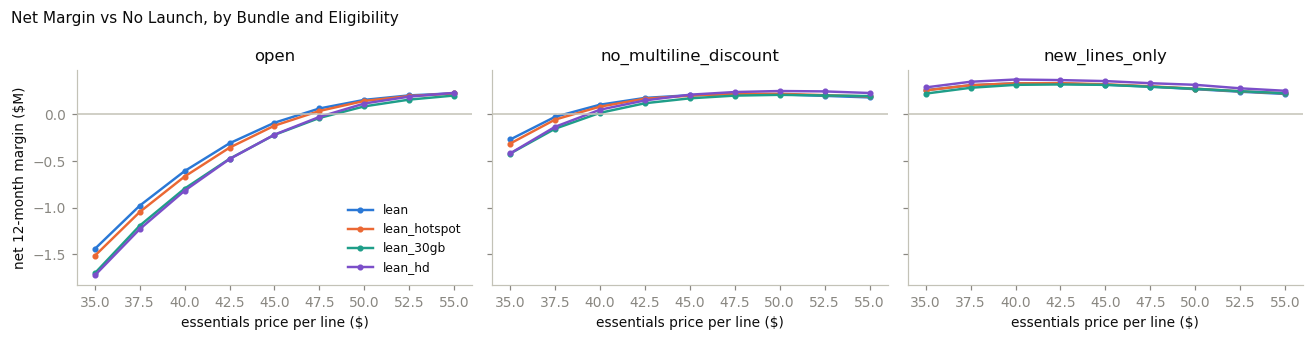

In [25]:
# Check Conjoint & Launch Answer Key
customer_classes = truth.loc[accounts['account_id'], 'latent_class'].value_counts(normalize = True)
sample_classes = truth.loc[conjoint_respondents.loc[conjoint_respondents['is_customer'], 'respondent_id'], 'latent_class'].value_counts(normalize = True)
display(pd.DataFrame({'customer base': customer_classes, 'conjoint customers': sample_classes}).reindex(CLASSES).round(3).rename_axis(None))

profiles_only = conjoint[(conjoint['option'] != 'keep_current') & ~conjoint['is_holdout']]
display(profiles_only.groupby('price_per_line')['chosen'].mean().round(3).to_frame('choice share').rename_axis(None).T)

holdout_shares = (
    conjoint[conjoint['is_holdout'] & conjoint['chosen']]
        .merge(conjoint_respondents[['respondent_id', 'is_customer']], on = 'respondent_id')
        .groupby(['task', 'is_customer'])['option'].value_counts(normalize = True).unstack('option').fillna(0)
)
display(holdout_shares.round(3).rename(index = {True: 'customers', False: 'non-customers'}, level = 'is_customer').rename_axis([None, None]).rename_axis(None, axis = 1))

display(
    summary['take rate'].unstack('essentials_price').loc[:, [40.0, 45.0, 50.0]].round(3)
        .join(summary['from premium/standard'].xs(REFERENCE_PRICE, level = 'essentials_price').round(3).rename('from premium/standard at $45'))
        .join(summary['net margin (12 mo, $M)'].xs(REFERENCE_PRICE, level = 'essentials_price').round(3).rename('net margin at $45 ($M)'))
        .rename_axis([None, None])
)

ref_households = counterfactual_launch[counterfactual_launch['essentials_price'] == REFERENCE_PRICE]
intensity = HH['launch_intensity'][ref_households['household_id'].to_numpy()]
own_b = ref_households['state_b'].isin(ALTS[:4]).to_numpy()
by_intensity = pd.Series(ref_households['state_b'].eq('essentials').to_numpy()[own_b]).groupby(intensity[own_b]).mean()
display(by_intensity.rename(index = {0: 'quiet', 1: 'standard', 2: 'heavy'}).round(3).to_frame('take rate at $45, lean, open').rename_axis(None))

fig, axes = plt.subplots(1, 3, figsize = (12, 3.1), sharey = True)
for ax, eligibility in zip(axes, ELIGIBILITY):
    for bundle, color in zip(ESSENTIALS_BUNDLES, [ACCENT, ACCENT2, '#1f9e89', '#7b4fc9']):
        s = summary.xs((bundle, eligibility), level = ['bundle', 'eligibility'])['net margin (12 mo, $M)']
        ax.plot(s.index, s.values, marker = 'o', markersize = 3, linewidth = 1.6, color = color, label = bundle)
    ax.axhline(0, color = BASELINE, linewidth = 1)
    ax.set_title(eligibility)
    ax.set_xlabel('essentials price per line ($)')
axes[0].set_ylabel('net 12-month margin ($M)')
axes[0].legend(frameon = False, fontsize = 8)
fig.suptitle('Net Margin vs No Launch, by Bundle and Eligibility', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()